In [1]:
!pip3 install pandas umap-learn matplotlib seaborn


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# <font color='#3c3c3c'>Introduction</font>

Music plays a powerful role in shaping human emotions, whether it's used as a mood booster, coping mechanism for sadness, or even as a way to calm nerves during stressful situations. In today’s streaming platforms, mood based personalization is a main factor when it comes to user engagement. However, accurately identifying the mood of a song based on audio features is a challenging task.

This project explores how machine learning can connect the emotions music listeners feel and the data that models can analyze. We first use unsupervised clustering to define meaningful mood labels based on the audio features of songs.

These labels are then used to train and evaluate a range of supervised classification models.
Our goal is to simulate how a machine might “listen” to a song and infer its vibe, helping move music recommendation systems one step closer to emotional intelligence.

# <font color='#3c3c3c'>EDA1: Pre Mood Column</font>

In [3]:
df = pd.read_csv("SpotifyFeatures.csv")
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


### <font color='6e6e6e'>Basic general analysis</font>

The first step we took was to find out some basic information about our dataset, such as the shape of the dataset, the names of the columns available, any missing values, and some general summary statistics. We also check for any duplicated values, to maintain a clean database. This way, we gain a general overview of the data we are working with.

Upon checking the shape and column names, as well as some summary stats, we observe:
- The dataset has 232725 rows and 18 columns.
- Most columns are numeric, which is preferred for ML models.
- There is only 1 missing value, track_name which has 232724 rows instead of 232725.
- key, mode, and time_signature are stored as 'object' type rather than numeric, so they will need to be converted into integers.
- Text columns, such as artist_name, track_name, and track_id, will most probably not be useful for predicting mood, and may be dropped in the future.
- Overall, the dataset seems clean and ready for preprocessing, with only some minor adjustments needed.

In [4]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns)

Dataset Shape: (232725, 18)

Column Names:
 Index(['genre', 'artist_name', 'track_name', 'track_id', 'popularity',
       'acousticness', 'danceability', 'duration_ms', 'energy',
       'instrumentalness', 'key', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'time_signature', 'valence'],
      dtype='object')


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232725 entries, 0 to 232724
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   genre             232725 non-null  object 
 1   artist_name       232725 non-null  object 
 2   track_name        232724 non-null  object 
 3   track_id          232725 non-null  object 
 4   popularity        232725 non-null  int64  
 5   acousticness      232725 non-null  float64
 6   danceability      232725 non-null  float64
 7   duration_ms       232725 non-null  int64  
 8   energy            232725 non-null  float64
 9   instrumentalness  232725 non-null  float64
 10  key               232725 non-null  object 
 11  liveness          232725 non-null  float64
 12  loudness          232725 non-null  float64
 13  mode              232725 non-null  object 
 14  speechiness       232725 non-null  float64
 15  tempo             232725 non-null  float64
 16  time_signature    23

The next step we took was to generate summary statistics for all of the numerical columns, in order to have a better idea of the feature scales, skewness, and any potential outliers that we should handle during preprocessing. Some key observations include:
1. Popularity:
    - The mean is 41.13, and the median is 43, indicating a roughly symmetric distribution.
    - The 25th percentile is 29, so most songs in this dataset are not very popular.
    - Std = 18.19, so a decent spread of popularity levels.
2. Acousticness:
    - Mean (0.369) > median (0.232), so it is a right skewed distribution
    - The 75th percentile is 0.722, meaning 75% of songs have acousticness below 0.722, This means most songs are not very acoustic.
    - The max val is close to 1, so some songs are fully acoustic. This reflects modern music trends, where most tracks are digitally produced.
    - Std = 0.355, showing high spread, so it is important for distinguishing acoustic/chill moods.
3. Danceability:
    - The mean (0.55) and median (0.57) are almost equal, suggesting a fairly symmetric distribution, so most songs are just moderately danceable.
    - This feature may help in differentiating between calm/chill (low danceability) or party/energetic (high danceability).
    - Std of 0.186, indicating moderate spread.
4. Duration:
    - The mean is 235000ms, so the average song lasts about 3.9 minutes.
    - The maximum song length is 5.5 million ms, which is around 92 minutes. This is an outlier we might have to deal with in the future.
    - The standard deviation is 118,936 ms, a very high spread mainly due to extreme outliers.
5. Energy:
    - Mean (0.57) < median (0.61), suggesting a slight left skew and a moderately energetic dataset.
    - Std = 0.263, implying a good spread and high predictive potential for energetic vs calm moods.
6. Instrumentalness:
    - Mean (0.15) > median (0.00004), so it is extremely right skewed.
    - 75% of songs < 0.036, so most songs contain vocals.
    - The standard deviation is 0.303, showing a high spread.
7. Liveness:
    - Max value of 1, meaning some live performances exist in the dataset.
    - Std of 0.198 indicates moderate spread, but weaker predictive power compared to other features.
8. Loudness:
    - A mean of -9.57dB, which is the spotify standard.
    - Min of -52dB, which could be silence or bad audio, and max of 3.74dB (unusually loud).
    - Std = 6 dB, so a very wide range of loudness levels, which could be important for capturing aggressive vs softer moods.
9. Speechiness:
    - Measures how much a track sounds like spoken words rather than musical singing.
    - Max of 0.97, may represent podcasts
    - Mean (0.12) > median (0.05), indicating high right skew (most songs are musical)
    - Std = 0.186, showing moderate spread.
10. Tempo:
    - Mean of 118 BPM matches most pop/rock music.
    - Wide range, (30-243) so most tracks are super slow/fast.
    - Std of 30.90 BPM, indicating high spread and good potential for predicting energetic vs calm moods.
11. Valence:
    - Positivity vs negativity. Mean (0.45) and median (0.44) are almost equal, indicating a centered distribution.
    - Std = 0.260, showing good spread across different emotional tones.
    - This may be very helpful for mood prediction, low valence may suggest sadness, and high happiness.

This statistical exploration allowed us to understand outliers, distributions, and spread of a feature. To better visualize the distributions of our features, we will actually plot the distributions in next steps.

In [6]:
df.describe()

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,232725.000000,232725.000000,232725.000000,2.327250e+05,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000,232725.000000
mean,41.127502,0.368560,0.554364,2.351223e+05,0.570958,0.148301,0.215009,-9.569885,0.120765,117.666585,0.454917
std,18.189948,0.354768,0.185608,1.189359e+05,0.263456,0.302768,0.198273,5.998204,0.185518,30.898907,0.260065
min,0.000000,0.000000,0.056900,1.538700e+04,0.000020,0.000000,0.009670,-52.457000,0.022200,30.379000,0.000000
25%,29.000000,0.037600,0.435000,1.828570e+05,0.385000,0.000000,0.097400,-11.771000,0.036700,92.959000,0.237000
50%,43.000000,0.232000,0.571000,2.204270e+05,0.605000,0.000044,0.128000,-7.762000,0.050100,115.778000,0.444000
75%,55.000000,0.722000,0.692000,2.657680e+05,0.787000,0.035800,0.264000,-5.501000,0.105000,139.054000,0.660000
max,100.000000,0.996000,0.989000,5.552917e+06,0.999000,0.999000,1.000000,3.744000,0.967000,242.903000,1.000000


A formal check for missing values using .isnull and .sum allows us to confirm what we observed earlier, only one missing value which is in track_name.

In [7]:
print("\nMissing Values:\n", df.isnull().sum())


Missing Values:
 genre               0
artist_name         0
track_name          1
track_id            0
popularity          0
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
key                 0
liveness            0
loudness            0
mode                0
speechiness         0
tempo               0
time_signature      0
valence             0
dtype: int64


Then, we check for any duplicate rows in the dataset. Thankfully, there were no duplicate rows and so no further action was necessary.

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
audio_features = ['valence', 'energy', 'danceability', 'acousticness', 'tempo', 'liveness', 'speechiness', 'instrumentalness', 'loudness']

### <font color='6e6e6e'>Valence distribution</font>

The plot below shows the distribution of the valence feature. This feature measures how happy and cheerful a song sounds. These values range from 0.0 (very sad and negative) to 1.0 (very happy and positive). We can observe that there is a spike near 0.0, which means that there is a high number of sad songs (low valence songs). Aside from that, the distribution is fairly uniform between 0.1 until 0.8. This indicates that the majority of the songs span across a broad emotional range. We can also note that there is a noticeable drop at 1.0, meaning that there are few songs with a truly happy or upbeat emotional tone. In addition, the skewness of 0.14, indicates that distribution is nearly symmetric, with only a very slight right skew that indicates there are more high valence songs than low valence near the tail. The kurtosis of -1.01 also highlights that the valence values are well distributed, as it means that our distribution is flatter than normal with lighter tails (so values are evenly spread out).

This distribution also highlights a possible mood labeling strategy that would quantify the emotional positivity or negativity of a song depending on our scale from 0 to 1. Since we have yet to explore the rest of the features though, this remains just an initial proposal. 


In [10]:
from scipy.stats import skew, kurtosis

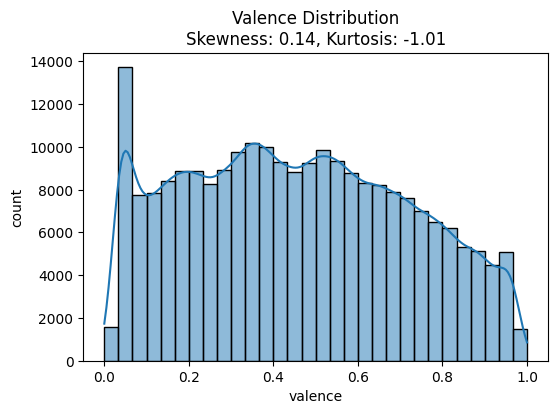

In [11]:
valence_skew = skew(df['valence'], nan_policy='omit')
valence_kurtosis = kurtosis(df['valence'], nan_policy='omit')

plt.figure(figsize=(6, 4))
sns.histplot(df['valence'], kde=True, bins=30)
plt.title(f'Valence Distribution\nSkewness: {valence_skew:.2f}, Kurtosis: {valence_kurtosis:.2f}')
plt.xlabel('valence')
plt.ylabel('count')
plt.show()

### <font color='6e6e6e'>Energy distribution</font>

The energy distribution is slightly left-skewed, with the highest frequency of values around 10,000 and the lowest around 4,500. The skewness of -0.40 confirms this leftward skew, meaning there are more high-energy values than low-energy values. We also printed the kurtosis value to better understand the shape of the distribution, -0.81. Since it is less than 0 then this means that it has a flatter peak and less outliers (extreme valies) than a normal distribution, making the overall distribution more spread out.

In the context of our model's objective, understanding the distribution of the song's energy is probably a strong predictor for mood since high-energy songs tend to be "happy" while low-energy songs tend to be sad. Results show that most songs in the dataset are moderately to highly energetic, which suggests the model will be trained on a dataset biased toward more upbeat or intense moods. So, we need to keep an eye out to handle this during the training. Despite the imbalance, the feature appears to be useful and unlikely to mislead the model due to noise or outliers.

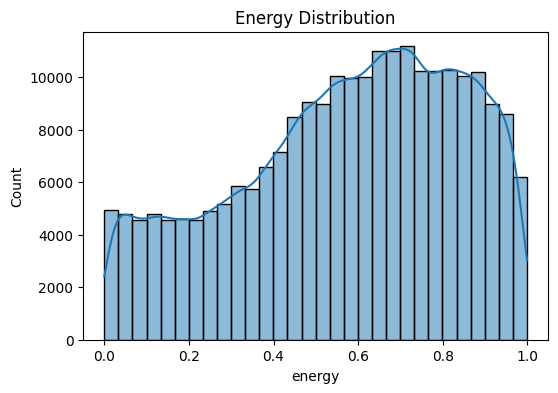

In [12]:
plt.figure(figsize=(6, 4))
sns.histplot(df['energy'], kde=True, bins=30)
plt.title('Energy Distribution')
plt.show()

In [13]:
print("Skewness:", df['energy'].skew())
print("Kurtosis:", df['energy'].kurt())

Skewness: -0.40022327921151274
Kurtosis: -0.8135949529345483


### <font color='6e6e6e'>Danceability distribution</font>

We can see that most songs fall in the mid-to-high danceability range, with the distribution peaking around 0.6. This suggests that a large portion of tracks in the dataset are moderately danceable, likely having steady rhythms and beats that are easy to move to. Very few songs have low danceability scores, meaning it's rare to find tracks that are difficult to dance to. The distribution is slightly left-skewed with a skewness of -0.38, indicating a small tail of less danceable songs. 

The kurtosis value of -0.37 tells us the distribution is relatively flat compared to a normal curve, meaning the values are more spread out and there are fewer extreme outliers. Overall, this aligns well with what we expect from a dataset of mainstream songs—most are produced with rhythm and groove in mind.

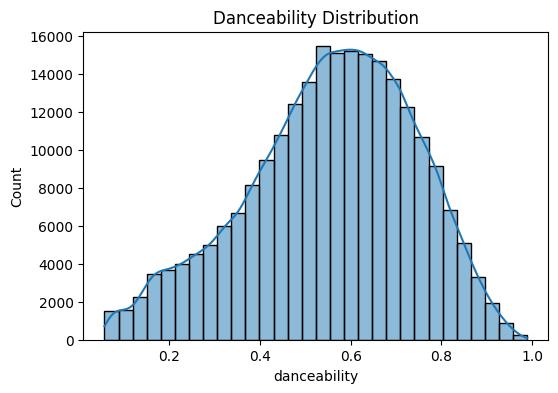

Skewness: -0.37827814005632515
Kurtosis: -0.3661368776600229


In [14]:
plt.figure(figsize=(6, 4))
sns.histplot(df['danceability'], kde=True, bins=30)
plt.title('Danceability Distribution')
plt.show()

print("Skewness:", df['danceability'].skew())
print("Kurtosis:", df['danceability'].kurt())

### <font color='6e6e6e'>Acousticness distribution</font>

We can see that most songs fall under the extremes with very few in the medium range(0.4-0.6) There is a huge spike on 0.0 meaning that they are likely electronic, synthetic, or heavy produced tracks. There is a smaller spike on 1.0 which means that these are acoustic, live recording etc. 

In what we saw in the stats table above we can see that this makes sense as the mean is 0.368 which means that it goes towards a lower acousticness

We can see that the skewness of the graph being 0.53, which is a positive skew, and it means that most songs have low acoustic content, with a long tail of high acoustic tracks.
The kurtosis being of -1.29 means that values are more evenly spread across the range with fewer extreme outliers

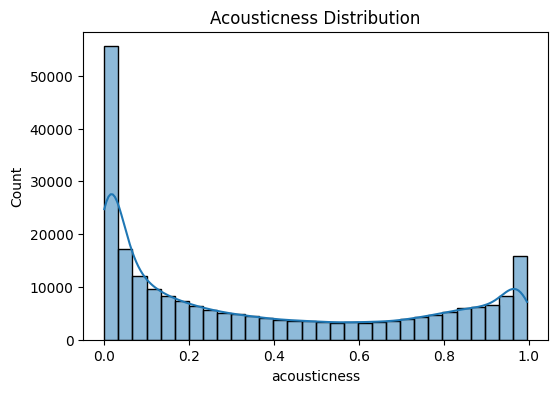

Skewness of acousticness: 0.53
Kurtosis of acousticness: -1.29


In [15]:
plt.figure(figsize=(6, 4))
sns.histplot(df['acousticness'], kde=True, bins=30)
plt.title('Acousticness Distribution')
plt.show()

acousticness_data = df['acousticness']

skewness = skew(acousticness_data)
kurt = kurtosis(acousticness_data)

print(f"Skewness of acousticness: {skewness:.2f}")
print(f"Kurtosis of acousticness: {kurt:.2f}")

### <font color='6e6e6e'>Tempo distribution</font>

The distribution of the tempo variable shows that most songs fall between the 90 and 130 bpm range. There's a clear peak around 100-110 bpm, which suggests that there is a presence of mid-tempo tracks maybe more chill and mainstream music. There is also a smaller bump around 120-130 bpm, meaning more energetic genres.

We can also see that tracks under 80 bpm are more uncommon, probably indicating sadder or mellow songs. On the other hand, we see a long tail of faster songs that go past 150 bpm. These might behave differently in mood prediction and could potentially act like outliers.

The skewness value of 0.403 indicates a mild right-skew. This confirms what we've discussed: basically that most songs are in the mid-tempo range, but there is a small group of faster tracks that extend the tail to the right. The kurtosis is -0.467, meaning the distribution is slightly flatter than a normal distribution. Tempo values are more spread out and less sharply peaked, but still fairly balanced and centered around a 90-130 bpm range. 

This plot helps us visualize and confirm what we see in the descriptive stats table above. With tempo values ranging from 30.38 bpm to 242.90 bpm, and having a mean of ~117.7 bpm and a median of ~115.8 BPM, we can assume tempo is slightly right-sweked. The spread, represented by std = 30.9, along with the kurtosis value suggest the dataset includes a good variety or tempo styles without extreme concetration in a specific range.

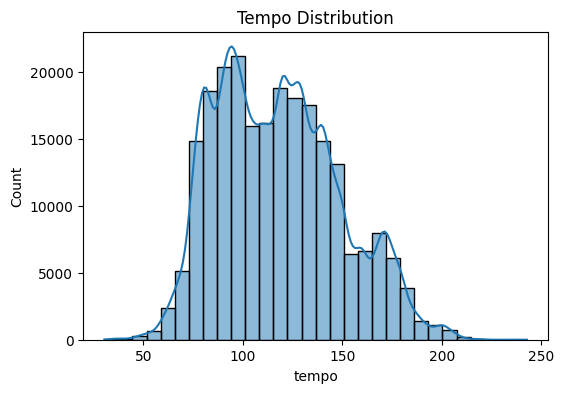

In [16]:
plt.figure(figsize=(6, 4))
sns.histplot(df['tempo'], kde=True, bins=30)
plt.title('Tempo Distribution')
plt.show()

### <font color='6e6e6e'>Liveness distribution</font>

Liveness is measuring the prescence of a live audience or live performance characteristics in a track, going from 0.0 to 1.0.  
The graph shows a strong positive skew since most values have a liveness close to 0, meaning a majority of tracks are studio recorded, not live. This is reinforced with the skewness of 2.07 (which implies a strong positive skew). The kurtosis of 3.89 indicates a high peak around 0.1 and a heavier tail, meaning that few songs deviate strongly from the norm. Since this distribution is highly skewed, using it in the model without any type of scaling or transformation could hurt performance. This is something we will take into account in future steps. From this graph, we can also conclude that liveness is likely not particularly useful when detecting mood since most values are concentrated under 0.3. 

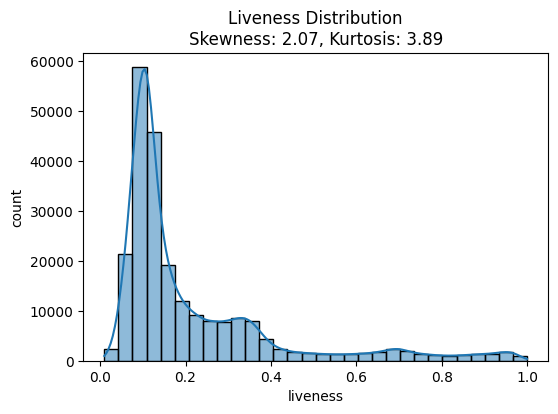

In [17]:
liveness_skew = skew(df['liveness'], nan_policy='omit')
liveness_kurt = kurtosis(df['liveness'], nan_policy='omit')

plt.figure(figsize=(6, 4))
sns.histplot(df['liveness'], kde=True, bins=30)
plt.title(f'Liveness Distribution\nSkewness: {liveness_skew:.2f}, Kurtosis: {liveness_kurt:.2f}')
plt.xlabel('liveness')
plt.ylabel('count')
plt.show()

### <font color='6e6e6e'>Speechiness distribution</font>

We can see that higher values indicate more speech-like content (such as podcasts, rap, or voiceovers), and lower values represent typical musical tracks with singing. 

We can see that the graph is highly right-skewed (3.31), with most values being concentrated around 0.0 which means that most of the songs have minimal-speech content. This makes sense since most songs are sung rather than spoken dialogues, which is how spotify actually measures speechiness.

 
The kurtosis of 10.98 means that there is a highly peaked distribution, it means that while most songs cluster around low speechiness, there are notable outliers with significant higher values which likely corresponds to genres with high spoken content such as rap, etc.

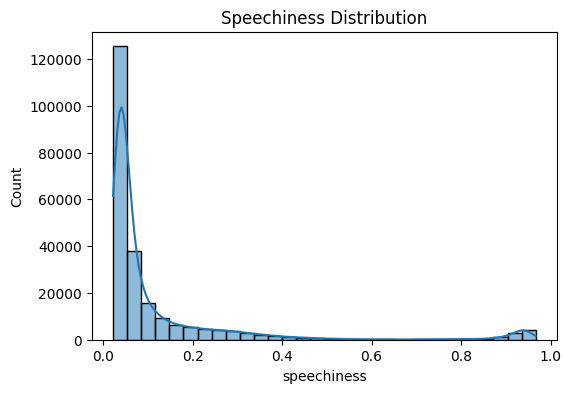

Skewness: 3.31
Kurtosis: 10.98


In [18]:
plt.figure(figsize=(6, 4))
sns.histplot(df['speechiness'], kde=True, bins=30)
plt.title('Speechiness Distribution')
plt.show()


speechiness_data = df['speechiness']
print(f"Skewness: {skew(speechiness_data):.2f}")
print(f"Kurtosis: {kurtosis(speechiness_data):.2f}")

### <font color='6e6e6e'>Instrumentalness distribution</font>

The distribution of the instrumentalness feature is heavily right-skewed. It has a significant peak near 0, which indicates that most tracks in the dataset have vocals. There is also a very small cluster of tracks with instrumentalness close to 1.0. These represent instrumental-only songs. These take up a small portion of the dataset, but they're still important because they may behave differently in mood modeling.

The instrumentalness distribution shows a strong right-skew, confirmed by a skewness of 1.820, meaning most tracks have very low instrumentalness.

The kurtosis is 1.588, indicating a distribution that is more peaked than normal, with heavy tails. This means while most songs cluster near zero, there’s a distinct minority of fully instrumental tracks that stand out at the upper end of the scale.

Lastly, the instrumentalness feature has a mean of ~0.15 and a median of 0.0, indicating that over half the tracks have no instrumental quality, in other words they contain vocals. The minimum, 25th, and 50th percentiles are all exactly 0.0, which show that the majority of tracks fall at the very bottom of the scale. However, the maximum value reaches 0.999, showing that some tracks are fully instrumental.

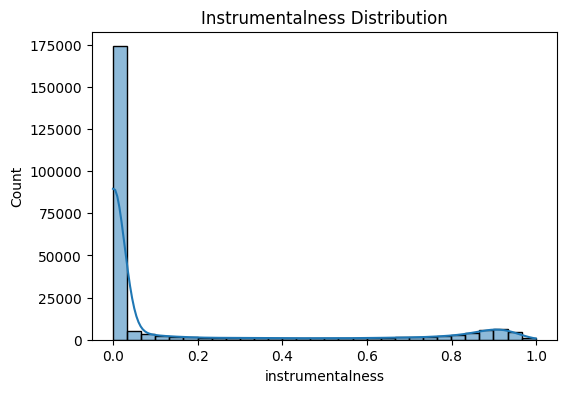

Instrumentalness Skewness: 1.820
Instrumentalness Kurtosis: 1.588


In [19]:
plt.figure(figsize=(6, 4))
sns.histplot(df['instrumentalness'], kde=True, bins=30)
plt.title('Instrumentalness Distribution')
plt.show()

inst_data = df['instrumentalness'].dropna()

inst_skew = skew(inst_data)
inst_kurt = kurtosis(inst_data)  

print(f"Instrumentalness Skewness: {inst_skew:.3f}")
print(f"Instrumentalness Kurtosis: {inst_kurt:.3f}")

### <font color='6e6e6e'>Loudness distribution</font>

The loudness feature in the dataset has values ranging from -52.46 dB to 3.74 dB, with a mean of -9.57 dB and a median of -7.76 dB. This means most tracks are fairly loud, represented by those close to 0 dB, while only a small minority are significantly quieter.

The distribution is left-skewed, the skewness being -1.662, which is clearly visible in the histogram. There’s a long tail of very quiet tracks pulling the distribution to the left.

The kurtosis is 3.207, indicating that the distribution is sharply peaked with heavy tails. This suggests that most tracks are clustered tightly around typical loudness values ( -10 to -5 dB), but there are outliers at both extremes (super loud and super soft).

To conclude, this means loudness is a solid feature for modeling the intensity of a track. Louder songs may correlate with high-energy or party moods, while quieter tracks could lean more toward chill, acoustic, or emotional vibes. This will all help in mood predicting.

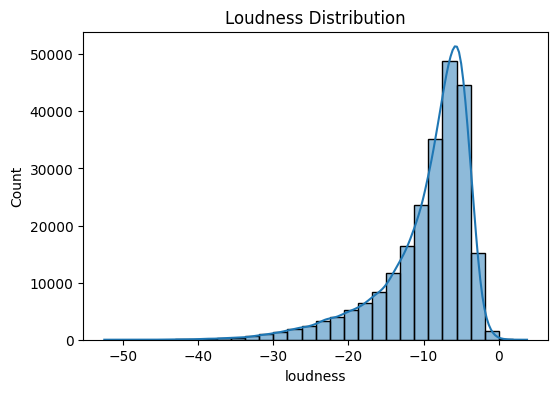

Loudness Skewness: -1.662
Loudness Kurtosis: 3.207


In [20]:
plt.figure(figsize=(6, 4))
sns.histplot(df['loudness'], kde=True, bins=30)
plt.title('Loudness Distribution')
plt.show()

loud_data = df['loudness'].dropna()

loud_skew = skew(loud_data)
loud_kurt = kurtosis(loud_data)  

print(f"Loudness Skewness: {loud_skew:.3f}")
print(f"Loudness Kurtosis: {loud_kurt:.3f}")

### <font color='6e6e6e'>Correlation map</font>

Now, to further analyze the relationship between the features, we have decided to print a correlation map since it's the easiest to visualize. If we consider those positive or negatives values greater than 0.6, then the graph shows three strong correlations. 
- **loudness vs acousticness (-0.69)**: This means that as the loudness of a track increases (strong negative correlation), the acousticness tends to decrease, and vice versa. In the context our model, this helps us better understand how "intense" or "natural" a song is. We could potentially remove one to decrease the number of features, but we beleive both are revelant since they describe different things.

- **energy vs acousticness (-0.73)**: This means that as the energy increases the acousticness decreases (strong negative correlation). Which makes sense since high-energy music often involves more synthesized or amplified sounds, whereas acoustic music tends to be calmer, with less energy.  This relationship reinforces the idea that energy could be an important feature for predicting moods like excited, angry, or happy, while acousticness might be more relevant for moods like calm or sad. Additionally, this is similar to the previous relationship, where we are not sure we should remove one or the other becuase both feature describe different things and can help predict different moods that are similar to just "happy" or "sad".

- **energy vs loudness (0.82)**: This means that as energy increases, so does the loudness (strong postive correlation). This is expected, as more intense and energetic music often has higher volumes and more dynamic sound. Since these features are more related to each other in terms of what they describe, typically upbeat, excited, or happy moods, maybe it we could drop one. 

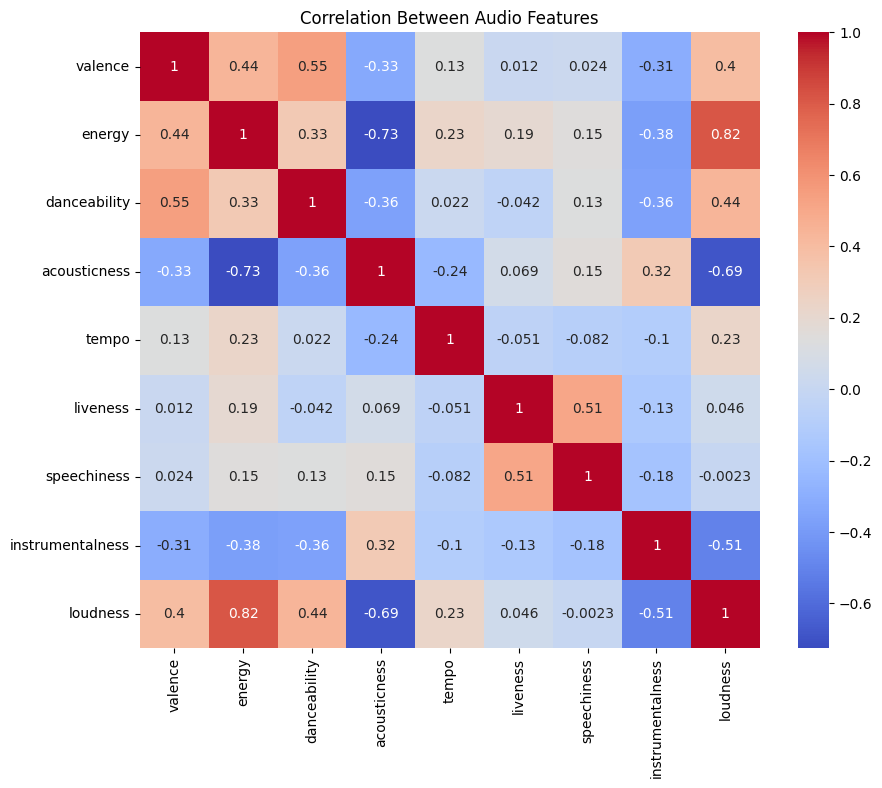

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[audio_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Audio Features')
plt.show()

### <font color='6e6e6e'>Genre analysis</font>

The first bar plot shows the top genres in the dataset, with each bar representing the number of tracks per genre. We can see that within these genres, there are roughly an equal amount of songs (nearly 1000)


The valence feature captures the musical positivity or emotional brightness of a song, where values closer to 1.0 indicate a happy, cheerful, or euphoric tone, and values near 0.0 suggest sadness, melancholy, or tension.

Analyzing valence across all genres in the dataset reveals distinct emotional profiles:
- Genres such as Pop, Reggae, Ska, Jazz, and Comedy show high median valence, indicating that these styles tend to produce more uplifting or feel-good tracks, consistent with their energetic or playful musical characteristics.

- Hip-Hop, Dance, Country, and Electronic display moderate valence levels, reflecting a mix of emotional tones depending on lyrical content and production style.

- On the lower end, Soundtrack, Opera, and Classical genres have notably lower median valence, with many tracks clustering near 0.2 or below. This suggests these genres are often composed to evoke more emotional depth, tension, or introspection.

- Interestingly, Children’s Music shows a bimodal distribution, with both very high and very low valence songs, likely due to its diversity between upbeat singalongs and calm lullabies.

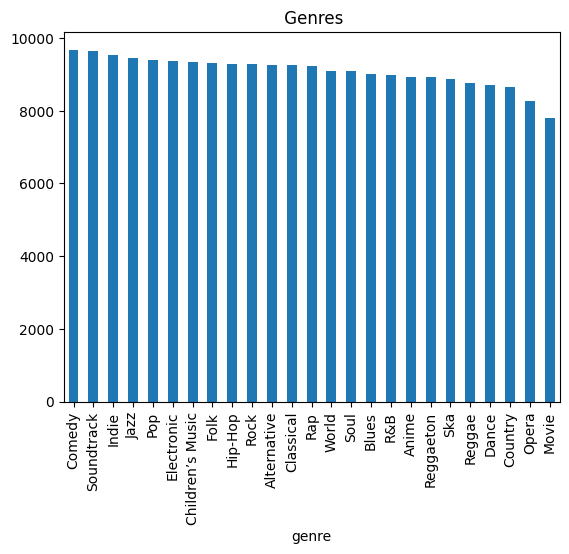

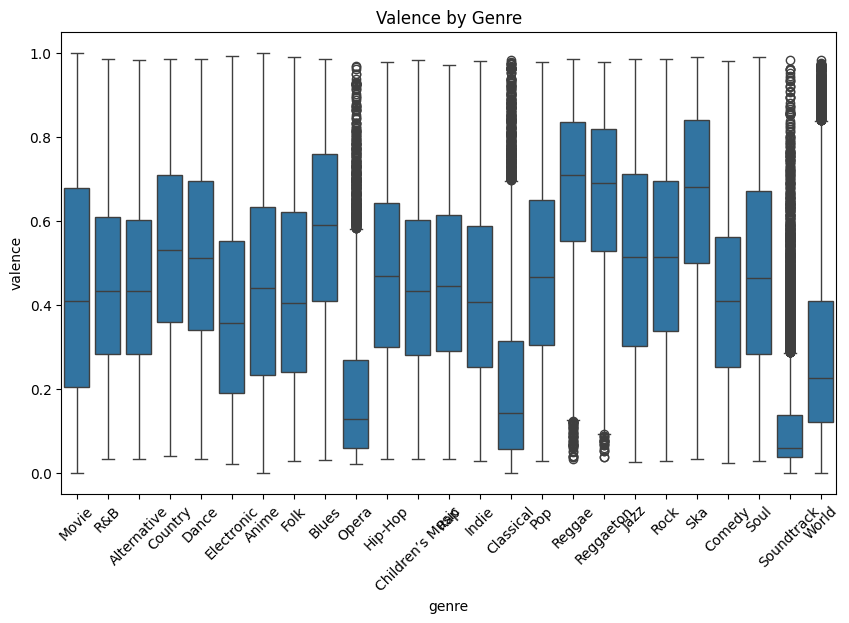

In [22]:
df['genre'].value_counts().head(25).plot(kind='bar')
plt.title(' Genres')
plt.show()

top_genres = df['genre'].value_counts().head(25).index
subset = df[df['genre'].isin(top_genres)]

plt.figure(figsize=(10, 6))
sns.boxplot(x='genre', y='valence', data=subset)
plt.title('Valence by Genre')
plt.xticks(rotation=45)
plt.show()

### <font color='6e6e6e'>Outlier check</font>

The next step we decided to conduct was a formal outlier check using boxplots, to better visualize and confirm the analysis discussed earlier. Outlier detection is focused on the numeric features, as categorical outliers are not exactly outliers, just rare.

From the plots, we can observe:
- valence, energy, and danceability are normalized between 0 and 1, and contain minimal/no outliers
- tempo has some high end outliers, with BMP above 200, indicating there are some songs that are faster than the average song.
- acousticness does not have formal outliers, however it is heavily right skewed.
- duration contains extreme outliers, with some tracks lasting millions of seconds (over an hour). These may represent podcasts for example.

Most mood related features, such as valence, energy, and danceability are fairly consistent. Temp and acousticness show some variability, but this may be useful for finding distinct mood clusters. If kept, duration includes extreme values that may need to be dealt with if they are just noise before any model training.

Using IQR, we also counted the extreme outliers, and observed tempo has 168 extreme outliers, and duration 14651. Our plan for now is to keep tempo but scale it appropriately, and if used remove extreme values from duration.

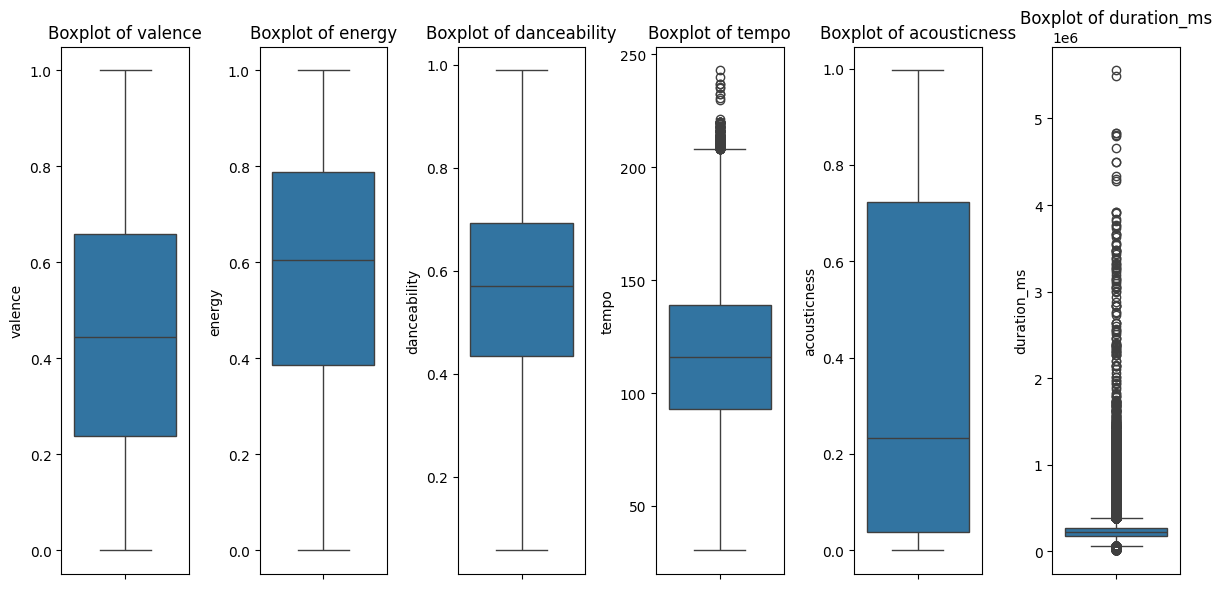

valence: 0 outliers
energy: 0 outliers
danceability: 0 outliers
tempo: 168 outliers
acousticness: 0 outliers
duration_ms: 14651 outliers


In [23]:
numeric_features = ['valence', 'energy', 'danceability', 'tempo', 'acousticness', 'duration_ms']

plt.figure(figsize=(12, 6))

for i, feature in enumerate(numeric_features, 1):
    plt.subplot(1, 6, i)
    sns.boxplot(y=df[feature])
    plt.title(f"Boxplot of {feature}")

plt.tight_layout()
plt.show()

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"{col}: {len(outliers)} outliers")

Since we observed extreme outliers in duration, we hypothesized earlier that they may be podcasts. To better understand our outliers, we sorted the dataset by duration in descending order and examined the top entries.

Many tracks were around 70-90 minutes long, such as:
- Episode 15 and episode 14, which must be a podcast
- 6:00 AM, which seems to be a continuous mix of music
- Lost Lands 2017 mix, which seems to be a DJ mix
- Nature Sounds for Sleep, which is a sleep audio

These are clearly not standard songs, and they may bias the model as their unusually long durations do not reflect the average song. In the end, we will most probably exclude tracks longer than 15 minutes to reflect real world song lengths and maintain consistency so that real music is the main focus.

In [24]:
long_tracks = df.sort_values(by='duration_ms', ascending=False)

long_tracks[['track_name', 'artist_name', 'duration_ms', 'genre']]
long_tracks['duration_min'] = long_tracks['duration_ms'] / 60000
long_tracks[['track_name', 'artist_name', 'duration_min', 'genre']].head(5)

,track_name,artist_name,duration_min,genre
212083,"Episodio 15 (Lady Orinoco, Políticas De Youtub...",La Mesa Reñoña,92.548617,Comedy
162671,6 : 00 Am,DJ Luigi,91.466667,Reggaeton
23593,Lost Lands 2017 Mix,Excision,80.510100,Electronic
211969,"Episodio 14 (Machismo, Juanga, Bebé a Bordo)",La Mesa Reñoña,80.509733,Comedy
219057,Nature Sounds for Sleep: Crackling Log Fire wi...,Jamie Llewellyn,80.066917,World


### <font color='6e6e6e'>Conclusions</font>

Our initial exploratory data analysis focused on gaining a foundational understanding of the Spotify dataset before applying any mood labeling. Key findings include:

Dataset Structure:
The dataset contains 232725 tracks and 18 columns, most of which are numerical audio features suitable for machine learning.
- A few non-numerical columns (track_name, artist_name, track_id) were identified as irrelevant for modeling and will be excluded.

Feature Quality
- Missing values were nearly non-existent, with only 1 missing entry in track_name.
- All mood-related features are numerical and normalized or easily scaled.
- Data types for key, mode, and time_signature were noted for possible conversion.

Distribution and Correlation
- Distribution plots showed that core features look good, with slight skew in acousticness and tempo.
- A correlation heatmap confirmed strong internal structure:
  - Energy and loudness are highly correlated (as expected).
  - Valence, danceability, and energy show useful, but not redundant, overlap.

Outlier Detection using boxplots and IQR:
  - Valence, energy, danceability, and acousticness had no extreme outliers.
  - Tempo showed 168 fast-paced outliers, likely representing high-BPM music.
  - Duration_ms had over 14,000 extreme outliers, with durations often exceeding 1 hour.
- Manual inspection of top-duration tracks revealed non-music content (podcasts, ambient soundtracks, comedy specials).


In conclusion, the dataset is clean, and structured. Core features behave predictably and show interpretable relationships. We are now ready to proceed to K-Means clustering to generate mood labels.

# <font color='#3c3c3c'>Creating Mood Clusters</font>

During our second part of data exploration, we realized that the dataset included 9681 tracks labeled under the “Comedy” genre. When we actually listened, these entries were not your typical songs but more spoken-words type of content, for example stand-up comedies or skits.	This makes them irrelevant for mood prediction.

To confirm this, we compared key audio features between comedy and non-comedy tracks using boxplots:
- Instrumentalness: Comedy tracks had almost zero instrumentalness, reflecting their wordy nature.
- Acousticness: Comedy entries showed consistently high acousticness, also suggesting they’re more based on speech.
- Valence: Less extreme values, but still comedy tracks tended toward lower valence scores, suggesting a more neutral tone.
- Energy: Slightly elevated energy on average and also included low-end outliers maybe because of inconsistent recording styles of comedy.

Including these tracks in our model analysis posted two main issues:
- They don’t convey musical mood in the same way songs do. This confused our model during mood prediction.
- As shown in the comparison boxplots, their values for audio features like valence, energy, acousticness, and instrumentalness don’t reflect typical musical structure and could add noise. 

As a result, we dropped all Comedy entries from the dataset.

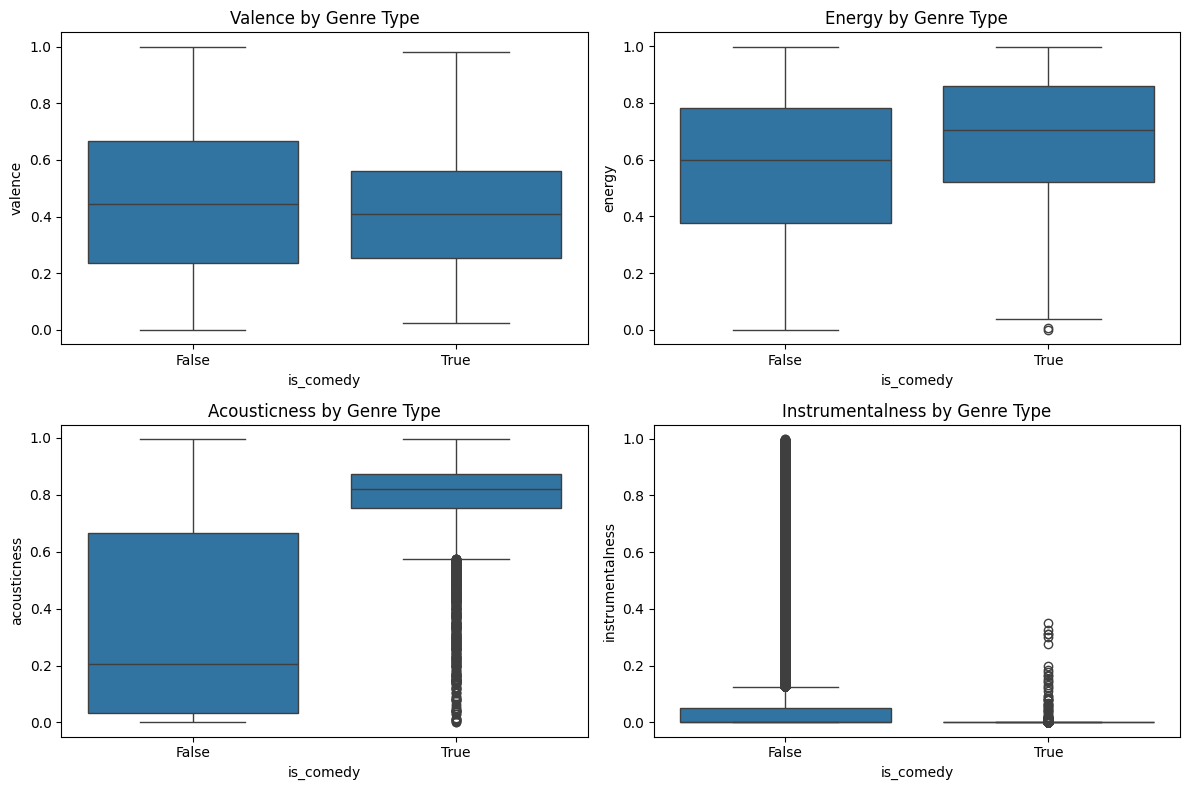

In [25]:
df['is_comedy'] = df['genre'] == 'Comedy'

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

features = ['valence', 'energy', 'acousticness', 'instrumentalness']
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(data=df, x='is_comedy', y=feature, ax=axes[i])
    axes[i].set_title(f'{feature.capitalize()} by Genre Type')

plt.tight_layout()
plt.show()

In [26]:
df.drop(columns='is_comedy', inplace=True)

In [27]:
print("Number of 'comedy' entries:", df[df['genre'] == 'Comedy'].shape[0])

Number of 'comedy' entries: 9681


In [28]:
df = df[df['genre'] != 'Comedy']

In [29]:
print("'comedy' entries remaining:", (df['genre'] == 'comedy').sum())

'comedy' entries remaining: 0


To avoid any risk of data leakage during this step, we worked with a copy of the original dataframe, named df_cluster, instead of modifying the original data directly. This way, all clustering logic is isolated and won’t affect downstream supervised learning unless explicitly added back. 
We picked a reduced set of features for clustering:
- Valence, energy, and acousticness.

We chose these based on intuition and EDA given that they’re conceptually tied to mood. Using a small number of core features reduces noise and helps interpret clusters.

We scaled these features using StandardScaler to ensure that K-Means wouldn't be biased by differences in scale, since K-Means is distance-based and unscaled values would distort the clustering.

Then, we trained the model with K=5 clusters using KMeans(n_clusters=5, random_state=42). We used 5 to allow a range of moods without breaking up the data too much.

The cluster assignments were stored in a new column called mood_cluster, and for convenience, we mapped the cluster numbers to string labels (Cluster 1, Cluster 2, …) as a placeholder. These can later be renamed to the actual mood labels like "Happy", "Sad", etc. We did this because it didn’t make sense to label the clusters directly with the moods because we didn’t know how K-means was gonna group them. We just wanted to listen to a few of the songs in each cluster to then identify what each of them represented.

Lastly, we copied these mood labels back into the original dataset under the column mood. This was the only point at which the original dataframe was modified with K-Means results; everything else was done separately in df_cluster.

Doing this before splitting the dataset is important because we’re using unsupervised learning to create labels. Also, no outcome variable is being predicted yet. Following this order, we made sure there’s no risk of data leakage.

In [30]:
df_cluster = df.copy()

# the three features we decided to cluster by 
clustering_features = ['valence', 'energy', 'acousticness']
X_cluster = df_cluster[clustering_features]

# just in case, we're creating a variable with the remaining numerical features 
full_features = [
     'danceability', 'tempo',
    'loudness', 'speechiness', 'instrumentalness', 'liveness'
]
X_full = df[full_features]

In [31]:
from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)

In [32]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
df_cluster['mood_cluster'] = kmeans.fit_predict(X_cluster_scaled)

# initially, the clusters were labeled numerically (0–4) since we didn’t yet know their mood semantics.
# after performing EDA and analyzing the characteristics of each cluster, we revisited this step and manually mapped each cluster to a mood label.
cluster_to_mood = {
    0: 'Happy',
    1: 'Calm',
    2: 'Content',
    3: 'Mellow',
    4: 'Energetic'
}
df_cluster['mood'] = df_cluster['mood_cluster'].map(cluster_to_mood)  

In [33]:
df['mood'] = df_cluster['mood']

In [34]:
df['mood'].nunique()

5

After generating multiple cluster visualizations using PCA, we decided to move forward with 5 clusters for the mood classification. As shown by the plots, we tested different values of k (4 and 6 in this case), and visually analyzed the separation and structure of the resulting groups.

- With 4 clusters, we noticed the groups were too broad. Two of them were especially dominant and seemed like it might be putting different moods together. It looked clean, but it was oversimplified and didn’t reflect some of the expected nuance we see in song moods.

- With 6 clusters, we ran into the opposite problem, some clusters started to overlap by a lot, and it seemed like the separation between moods became less clear. It looked messy and harder to interpret.

- Finally, with 5 clusters, the balance felt right. We thought he visual separation in the PCA plot looked promising because each cluster formed a distinct region with minimal overlap. This one gave us enough to capture a good amount of different moods without overcomplicating the labels.

In [35]:
import plotly.express as px
from sklearn.decomposition import PCA
import matplotlib.colors as mcolors  # Correct import for color conversion

# PCA transformation
pca = PCA(n_components=2)
components = pca.fit_transform(X_cluster_scaled)

# Add PCA components to DataFrame
df_cluster['pca1'] = components[:, 0]
df_cluster['pca2'] = components[:, 1]

# Get Set2 color palette from Matplotlib and convert RGB to hex
set2_colors = [mcolors.to_hex(c) for c in plt.get_cmap('Set2').colors]

# Create Plotly scatter plot using Set2 colors
fig = px.scatter(
    df_cluster,
    x='pca1',
    y='pca2',
    color='mood',
    title='Mood Clusters of Songs (PCA)',
    labels={'pca1': 'Principal Component 1', 'pca2': 'Principal Component 2'},
    hover_data=['mood_cluster'],
    color_discrete_sequence=set2_colors
)

# Make text larger
fig.update_layout(
    width=800,
    height=600,
    title_font=dict(size=30),
    legend_title=dict(font=dict(size=16)),
    legend=dict(font=dict(size=14))
)

fig.update_xaxes(title_font=dict(size=18), tickfont=dict(size=14))
fig.update_yaxes(title_font=dict(size=18), tickfont=dict(size=14))

fig.show()


In [36]:

def plot_kmeans_clusters(X_scaled, k, feature_df, color_list=None):
    """
    Fits KMeans and PCA, and plots scatter plot of clusters using matplotlib.

    Parameters:
        X_scaled (np.array): Scaled features for clustering
        k (int): Number of clusters
        feature_df (pd.DataFrame): Original dataframe to copy for plotting
        color_list (list): Optional list of fixed colors (hex or named)
    """

    # KMeans clustering
    kmeans = KMeans(n_clusters=k, random_state=42)
    clusters = kmeans.fit_predict(X_scaled)

    # PCA for dimensionality reduction
    pca = PCA(n_components=2)
    components = pca.fit_transform(X_scaled)

    # Build DataFrame for plotting
    plot_df = feature_df.copy().reset_index(drop=True)
    plot_df['mood_cluster'] = clusters
    plot_df['pca1'] = components[:, 0]
    plot_df['pca2'] = components[:, 1]

    # Default color palette if not provided
    if color_list is None:
        color_list = plt.get_cmap('Set2').colors  # 10 visually distinct colors

    # Ensure color_list has enough colors
    if k > len(color_list):
        raise ValueError(f"Color list must contain at least {k} colors.")

    # Assign colors to clusters
    cluster_colors = [color_list[i] for i in clusters]

    # Plot
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(
        plot_df['pca1'], plot_df['pca2'],
        c=cluster_colors,
        alpha=0.75,
        s=100
    )


    # Create legend
    legend_labels = [f"Cluster {i}" for i in range(k)]
    handles = [plt.Line2D(
        [0], [0], marker='o', color='w',
        label=legend_labels[i],
        markerfacecolor=color_list[i],
        markeredgecolor='black',
        markersize=10
    ) for i in range(k)]

    plt.legend(handles=handles, title="Cluster", frameon=True, fancybox=True)
    plt.title(f'Mood Clusters (k={k}) - PCA Projection', fontsize=14)
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

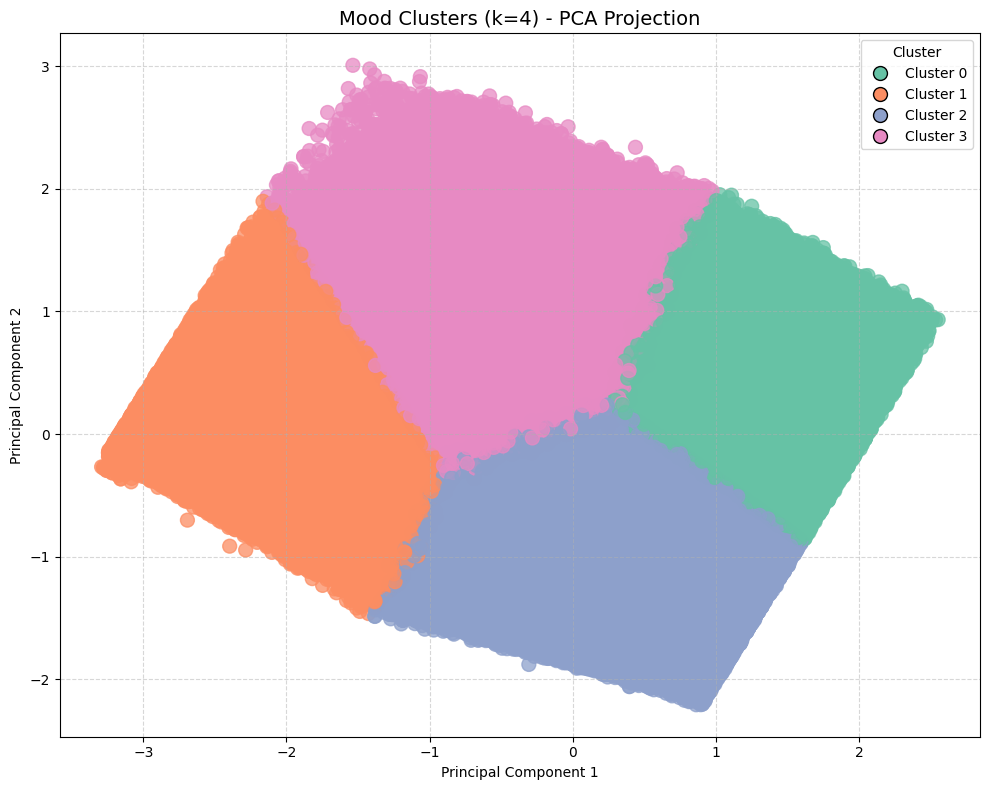

In [37]:
plot_kmeans_clusters(X_cluster_scaled, 4, df_cluster)

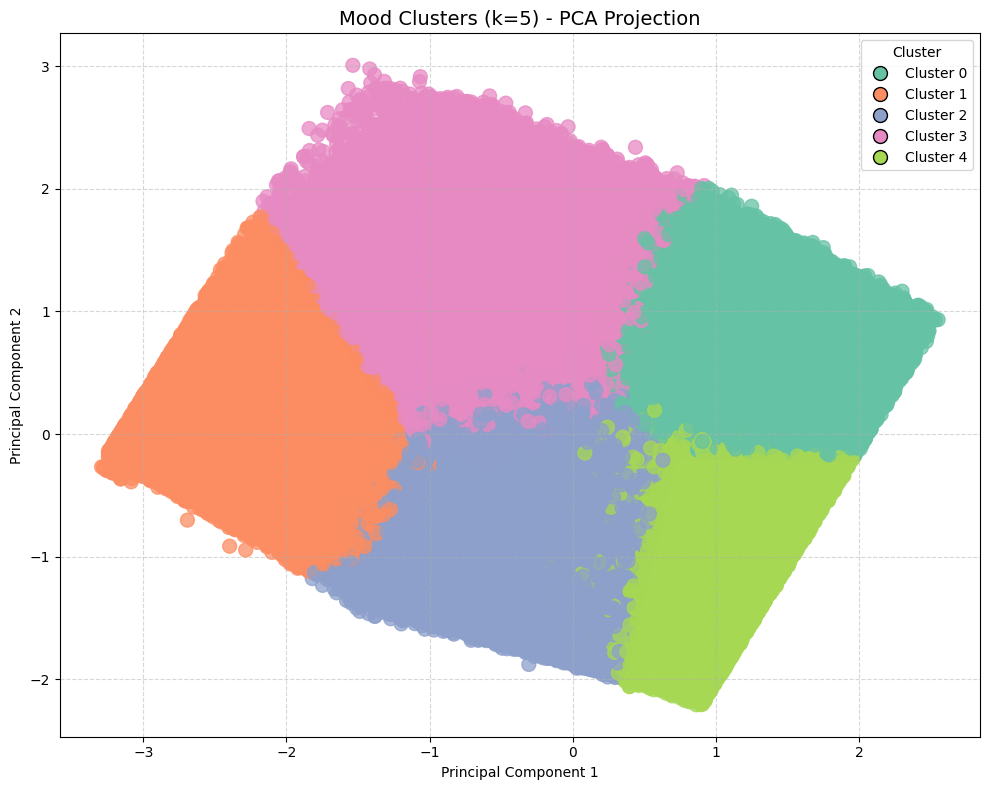

In [38]:
plot_kmeans_clusters(X_cluster_scaled, 5, df_cluster)

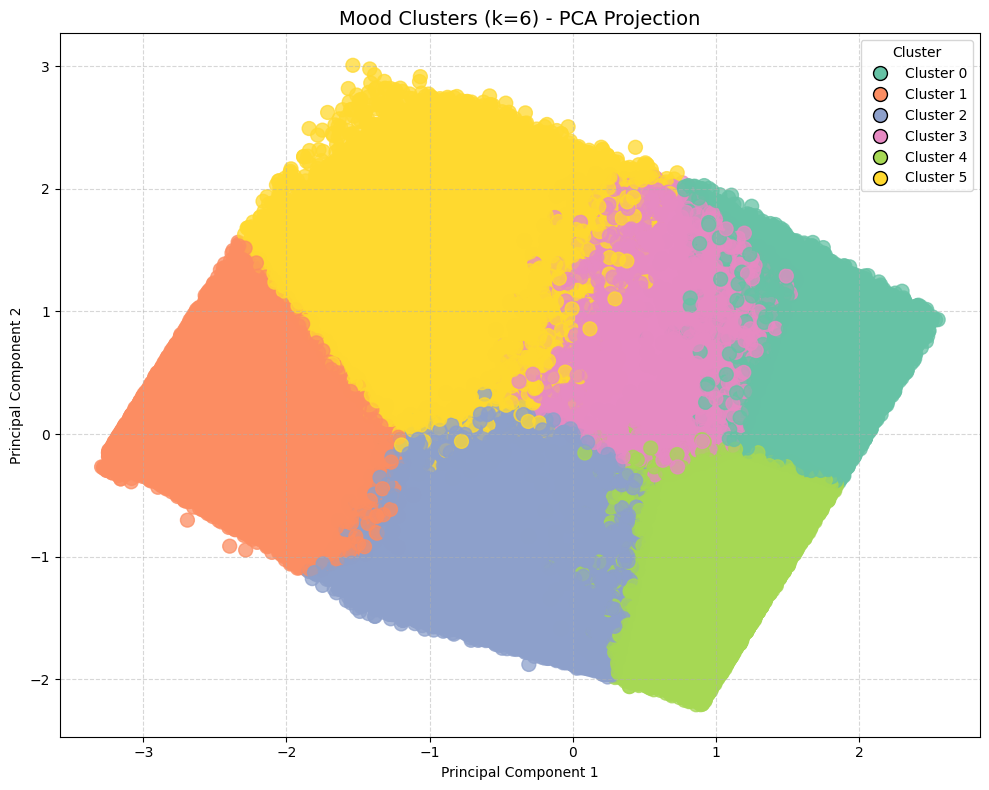

In [39]:
plot_kmeans_clusters(X_cluster_scaled, 6, df_cluster)

# <font color='#3c3c3c'>EDA2: Post Mood Column</font>

### <font color='6e6e6e'>Setting mood clusters</font>

After concluding the best number of clusters for our target feature is 5, now we have to identify what each cluster actually represents in terms of “mood”. First we decided it was a good idea to print 10 random songs from each cluster and listen to the songs ourselves. We also used the genre distributions within the clusters as a way to guide our process. The following are what we decided each sample of songs made us feel.

In [40]:
# Randomly printing 10 songs from each cluster 
for cluster_id in range(5):
    print(f"\nCluster {cluster_id}")
    display(
        df_cluster[df_cluster['mood_cluster'] == cluster_id][
            ['track_name', 'artist_name', 'genre','valence', 'energy', 'acousticness']
        ].sample(10, random_state=42)
    )


Cluster 0


,track_name,artist_name,genre,valence,energy,acousticness
91351,Bébé,MHD,Hip-Hop,0.839,0.672,0.16200
75904,6 In 2 Days,Music with Brian,Children's Music,0.749,0.893,0.00156
177286,We Can Do It,Jamiroquai,Jazz,0.911,0.776,0.00434
215381,More Than I Know,Jordan Davis,Country,0.654,0.917,0.02790
56625,Lil Bit,K CAMP,R&B,0.698,0.634,0.43900
25881,A Different Way,DJ Snake,Electronic,0.580,0.752,0.48800
192683,"You're The First, The Last, My Everything",Barry White,Soul,0.927,0.590,0.00367
188510,Honour Your Mother and Father,Desmond Dekker,Ska,0.856,0.573,0.07820
93844,Heavy,POWERS,Indie,0.856,0.686,0.00665
18523,Elevate,Big Time Rush,Dance,0.622,0.860,0.02800



Cluster 1


,track_name,artist_name,genre,valence,energy,acousticness
493,Marty And Henry,Randy Newman,Movie,0.0382,0.0317,0.987
43060,Ultralight Beam,Local Natives,Folk,0.2000,0.0975,0.939
80430,Act II: Vissi d'arte,Giacomo Puccini,Opera,0.0589,0.2160,0.991
129466,Bifu,Somei Satoh,Classical,0.0268,0.0390,0.979
104102,"Concerto No. 2 in E-Flat Major, K.417: III. Ro...",Wolfgang Amadeus Mozart,Classical,0.4950,0.0738,0.992
202075,Work The Problem,Harry Gregson-Williams,Soundtrack,0.0647,0.1450,0.623
203736,Pink,David Arnold & Michael Price,Soundtrack,0.0766,0.0617,0.911
98512,Other Side Of The Game,Erykah Badu,Children’s Music,0.1970,0.2620,0.486
211137,Daydream (feat. Ashwin Srinivasan),Nitin Sawhney,World,0.4590,0.1480,0.974
167172,Like An Angel,Anne Sofie von Otter,Classical,0.1210,0.0831,0.966



Cluster 2


,track_name,artist_name,genre,valence,energy,acousticness
121020,Southern Hospitality,Jelly Roll,Rap,0.3900,0.606,0.1000
213632,Son of the South,Upchurch,Country,0.1360,0.706,0.0130
146662,Lately,Anita Baker,Jazz,0.2680,0.544,0.4120
115583,Like Dat,Kodak Black,Rap,0.4820,0.476,0.0291
209838,The Pure and the Damned,Oneohtrix Point Never,World,0.0394,0.191,0.3590
155405,Alyssa Lies,Jason Michael Carroll,Rock,0.4140,0.597,0.3090
19324,Getting Over You - R3HAB Remix,Lauv,Dance,0.1180,0.646,0.0310
6056,Isn't He (This Jesus) [feat. Natalie Grant],Natalie Grant,Alternative,0.0622,0.467,0.1180
86146,If You,Silk,R&B,0.3360,0.477,0.1840
119683,A Spike Lee Joint (feat. Anthony Flammia),Flatbush Zombies,Rap,0.4840,0.511,0.1390



Cluster 3


,track_name,artist_name,genre,valence,energy,acousticness
146544,L-O-V-E,Gregory Porter,Jazz,0.531,0.279,0.697
150272,Gold,Sam Feldt,Pop,0.539,0.703,0.539
194734,"Emilie Jolie & le conteur, Pt. 2",Henri Salvador,Movie,0.788,0.424,0.339
138075,Don't Dis Me,Vybz Kartel,Reggae,0.855,0.474,0.464
110879,Save Myself,Ed Sheeran,Pop,0.481,0.290,0.850
118297,Stay,Iamjakehill,Rap,0.857,0.668,0.811
73845,The House That Jack Built,Kimbo Children's Music,Children's Music,0.672,0.239,0.705
231576,Moon Dogs,SALES,Soul,0.580,0.363,0.761
180638,Mr. Broadway - Live,Dave Brubeck,Jazz,0.561,0.399,0.319
205670,Morning On Boston Common,Randy Edelman,Soundtrack,0.589,0.395,0.963



Cluster 4


,track_name,artist_name,genre,valence,energy,acousticness
49869,Bad Blood,Black Pistol Fire,Blues,0.355,0.820,0.017300
89392,Window Shopper,50 Cent,Hip-Hop,0.467,0.628,0.107000
121431,Ashley,Big Sean,Rap,0.433,0.910,0.091900
84501,Don't Be Gone Too Long,Chris Brown,R&B,0.435,0.791,0.258000
99564,The Hangman's Body Count,Volbeat,Children’s Music,0.284,0.948,0.000059
1851,Our God,Chris Tomlin,Alternative,0.216,0.778,0.009980
11979,Restless Year,Ezra Furman,Alternative,0.489,0.947,0.031100
154231,Will The Circle Be Unbroken - Live,Warren Haynes,Rock,0.293,0.745,0.186000
3241,You,Candlebox,Alternative,0.599,0.861,0.007890
147403,Tooth and Claw,Animals As Leaders,Jazz,0.253,0.967,0.000546


**Cluster 1: Happy**

 This cluster stood out due to its high valence and high energy, evoking feelings of joy, excitement, and sociability. Songs in this group were often upbeat, rhythmically vibrant, feel-good and catchy. Genres like commercial pop, dance-pop, and reggae were prevalent here. When listening to these tracks, we felt genuinely uplifted and energized, making the “Happy” label an intuitive match for the cluster’s emotional and acoustic profile.

**Cluster 2: Calm**

Cluster 2 was defined by a sharp contrast in mood — lower valence, lower energy, and a strong acoustic presence. These tracks leaned more into minimal instrumentation and soft vocals. They made us feel introspective and even melancholic at times. The genre distribution here reflected this tone, with many examples falling into acoustic pop, indie folk, or slow singer-songwriter styles. This cluster reflects both the technical features and the somber, stripped-down emotional atmosphere these songs evoked.

**Cluster 3: Content**

This group had moderate valence and relatively low energy, but didn’t feel sad — rather, it felt calm, smooth, and laid-back. Listening to songs in this cluster gave us a sense of relaxation or even daydreaming, ideal for background listening while studying or winding down. These tracks often featured soft beats and light vocals. Genres like, lo-fi beats, soft R&B, or downtempo electronic were common. We labeled this “Content” because it captured that unique in-between mood: not quite happy or sad, but comfortably nonetheless.

**Cluster 4: Mellow**

Although similar in tempo and softness to "Content", this cluster leaned more into ambient and mellow musical territory. These songs felt even smoother and more emotionally neutral. The instrumentation was minimal, with a greater emphasis on texture and atmosphere than on rhythm or melody. We often heard instrumental tracks or very subtle vocal work, possibly coming from ambient, neoclassical, children's tunes or soft jazz genres. Compared to "Content", this cluster felt less structured and more passive, which is why we called it “Mellow".

**Cluster 5: Energetic**

This final cluster was the most intense. It featured very high energy values with a mix of valence — meaning the songs weren’t always happy, but they were often driving, loud, and fast-paced. Listening to these tracks gave us a rush and feeling of hype, often accompanied by strong percussion and dynamic instrumentation. Genres here ranged from electronic dance music to high-BPM rock or intense pop remixes. Whether the emotional tone was aggressive or motivational, what united these songs was their physicality. We named it “Energetic” to reflect this overwhelming sense of momentum and activation.


### <font color='6e6e6e'>Statistical justifications</font>

Since we can’t listen to around 200,000 to identify what each cluster represents, we decided to justify them statistically as well. First we printed the mean values of valence, energy, and acoustic ness of each cluster since those are the features that we believe makes it easier for us to identify what the song cluster represents in terms of mood and see if it goes along with what we felt while listening to the songs. 

In [41]:
cluster_summary = df_cluster.groupby('mood_cluster')[clustering_features].mean()
print(cluster_summary)

               valence    energy  acousticness
mood_cluster                                  
0             0.758946  0.741482      0.134775
1             0.173639  0.184282      0.877450
2             0.274675  0.513595      0.219184
3             0.639244  0.442294      0.671929
4             0.401377  0.821940      0.060605


**Cluster 1 - Happy**: It shows it has the highest valence value and the second highest energy level. This suggests that songs in this cluster have pretty high energy and the most “positiveness”. Low acousticness also implies a more electronic, upbeat feel, which definitely goes along with “happy”.

**Cluster 2 - Calm**: Results show the lowest valence and energy levels, which means that songs in this cluster are probably slow and soft. Additionally this cluster also has the highest level of acousticness which makes sense since slower songs tend to involve more “raw” instrument sounds rather than electronic which goes more with upbeat songs. 

**Cluster 3 - Content**: This cluster has average values for each feature. It shows moderate energy and low valence suggesting a neutral or laid-back state. So, not sad but not happy either. So, the songs in this cluster are probably easy to listen to on a daily basis when one is just “content”. 

**Cluster 4 - Mellow**: This cluster shows the second lowest level of energy, the second highest level of energy, and a moderate level of acousticness which goes along with mellow. The songs in this cluster are not sad, but they give a sense of melancholy while keeping the “vibe” of the songs a bit upbeat, in other words, mellow fits perfectly. 

**Cluster 5 - Energetic**: This cluster has the highest energy energy, low acousticness, and medium valence, which implies intensity. The medium valence suggests the songs are not necessarily joyful, but they’re highly stimulating.

### <font color='6e6e6e'>Analysis through genre</font>

To provide additional justification for our cluster labels, we plotted the proportions of each mood within every genre in the dataset. This provided us with insightful information about the clusters. 

For example, **Calm** is more present in “Classical”,  “Opera”, and “Soundtrack”. Considering we clustered based on valence, energy, and acousticness, this goes along with the label because these genres typically feature lower energy and higher acousticness, which align with the characteristics of calm music. 

**Content** shows a relatively even distribution across most genres, except for “Children’s Music,” “Classical,” “Movie,” and “Ska.” This pattern aligns well with the nature of the “Content” cluster, which reflects balanced levels of valence and energy, indicating emotional stability without intense highs or lows. Genres where “Content” is less common tend to evoke more pronounced or dynamic emotions, which explains their divergence from this cluster’s calm and steady characteristics. 

**Energetic** is very present in high-energy genres such as “Electronic,” “Alternative,” and “Children’s Music.” This aligns well with the characteristics of this cluster, which features high energy levels combined with moderate levels of valence and low acousticness, traits commonly found in these lively and upbeat genres. 

Similarly, **Happy** is predominantly found in high-valence genres such as “Reggae” and “Reggaeton.” This makes sense because these genres are known for their upbeat, positive vibes, which align closely with the elevated valence values characteristic of the “Happy” cluster. 

Finally, **Mellow** is primarily associated with genres characterized by high acousticness, such as “Jazz,” “Blues,” and “Movie” soundtracks. This fits well with the cluster’s traits, reflecting smooth, softer sounds with low valence and energy levels. 

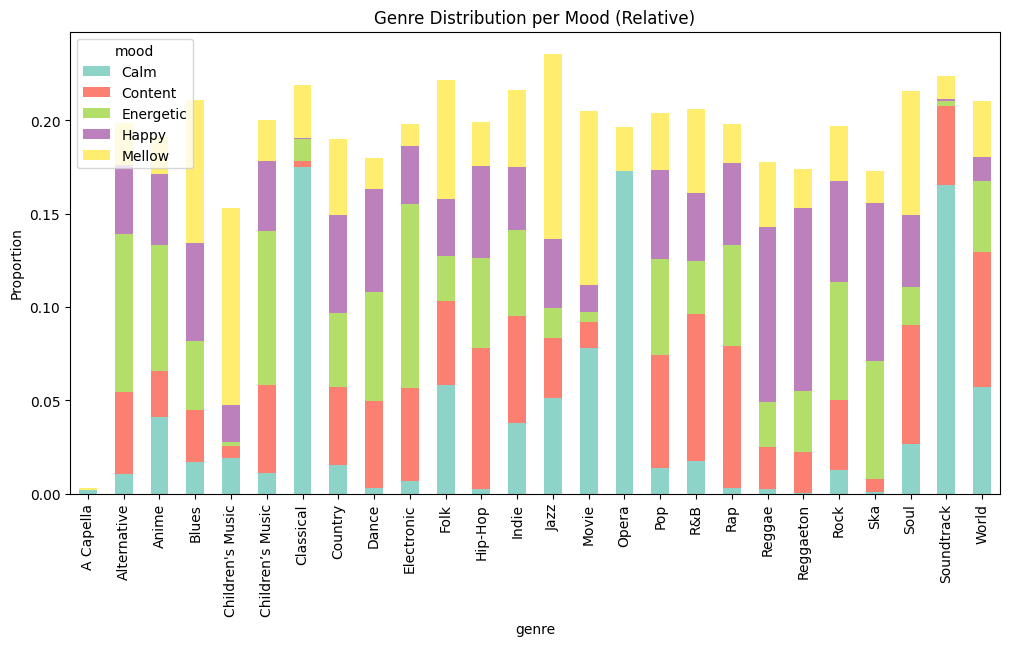

In [42]:
genre_mood_ct = pd.crosstab(df['mood'], df['genre'])
genre_mood_ct = genre_mood_ct.div(genre_mood_ct.sum(axis=1), axis=0)

genre_mood_ct.T.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='Set3')
plt.title("Genre Distribution per Mood (Relative)")
plt.ylabel("Proportion")
plt.show()

### <font color='6e6e6e'>Feature by mood</font>

The radar graph above has the purpose of showing how present the remaining sound features are in each cluster. 

**Calm**: This cluster is the only cluster with extreme levels of “instrumentalness” and no measure of the rest because of their low levels of presence. This makes sense because calm tracks often rely on instrumental elements and minimal additional features, emphasizing soothing and sparse soundscapes.

**Content**: As expected, this cluster has low to moderate levels of all features. This reflects a balanced and stable sound profile consistent with a neutral emotional state without strong energetic or dynamic characteristics.

**Energetic**: This cluster has the highest levels of “liveness”, “loudness”, and “tempo”. These elevated values align perfectly with the energetic nature of the cluster, capturing its vibrant and active sound signature.

**Happy**: This cluster has the highest level of danceability and pretty high levels of “speechiness”, “tempo”, and “loudness”. These traits correspond well with upbeat, engaging, and lively music that encourages movement and positive moods.

**Mellow**: This cluster has the highest level of “speechiness” and low levels of “tempo” and “loudness”. Although the high danceability might seem contradictory at first, it reflects a groove-oriented, easy-listening style where rhythm and beat encourage gentle movement without requiring fast tempos or loud sounds. 

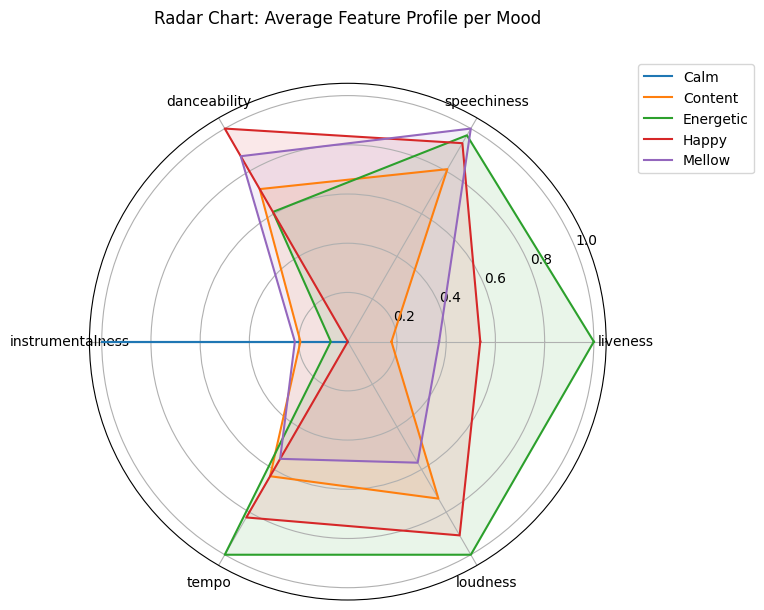

In [43]:
# all numerical features (except the ones we sued for clustering)
radar_features = ['liveness', 'speechiness', 'danceability', 'instrumentalness', 'tempo', 'loudness']

# Compute mean of each feature per mood
radar_data = df.groupby('mood')[radar_features].mean()

# Normalize features for better comparison (0–1 scale)
radar_data_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min())
# Number of features
labels = radar_features
num_vars = len(labels)

# Angles for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # complete the loop
# Create plot
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot each mood
for mood in radar_data_norm.index:
    values = radar_data_norm.loc[mood].tolist()
    values += values[:1]  # close the polygon
    ax.plot(angles, values, label=mood)
    ax.fill(angles, values, alpha=0.1)

# Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_title("Radar Chart: Average Feature Profile per Mood", y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.05))
plt.tight_layout()
plt.show()

The following graphs just validate further what was anlyzed in the radar graph. 

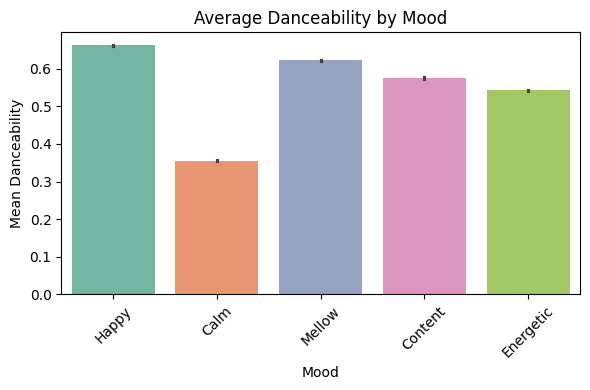

In [44]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='mood', y='danceability', hue='mood', palette='Set2', legend=False)
plt.title('Average Danceability by Mood')
plt.xlabel('Mood')
plt.ylabel('Mean Danceability')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

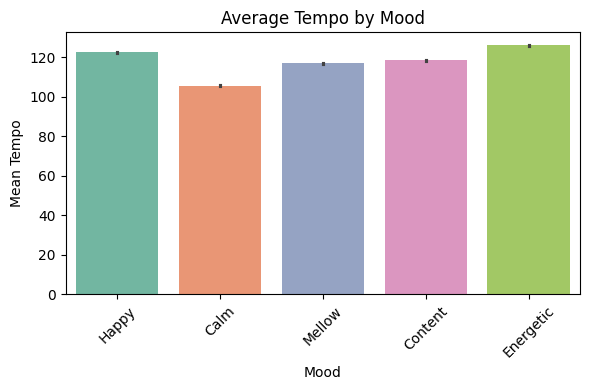

In [45]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='mood', y='tempo', hue='mood', palette='Set2', legend=False)
plt.title('Average Tempo by Mood')
plt.xlabel('Mood')
plt.ylabel('Mean Tempo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

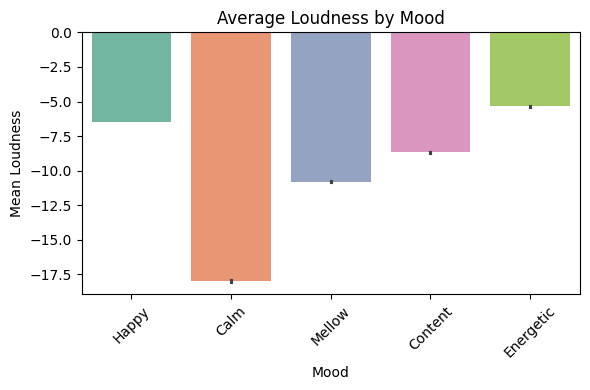

In [46]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='mood', y='loudness', hue='mood', palette='Set2', legend=False)
plt.title('Average Loudness by Mood')
plt.xlabel('Mood')
plt.ylabel('Mean Loudness')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

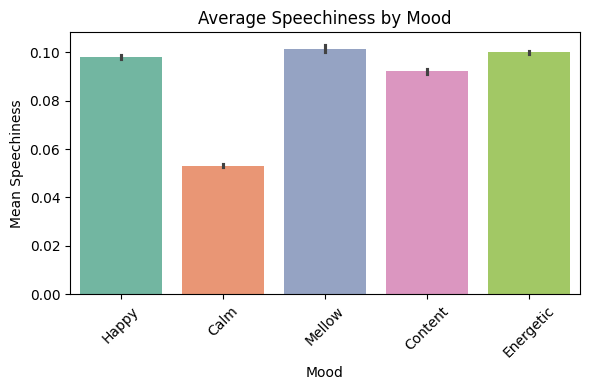

In [47]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='mood', y='speechiness', hue='mood', palette='Set2', legend=False)
plt.title('Average Speechiness by Mood')
plt.xlabel('Mood')
plt.ylabel('Mean Speechiness')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

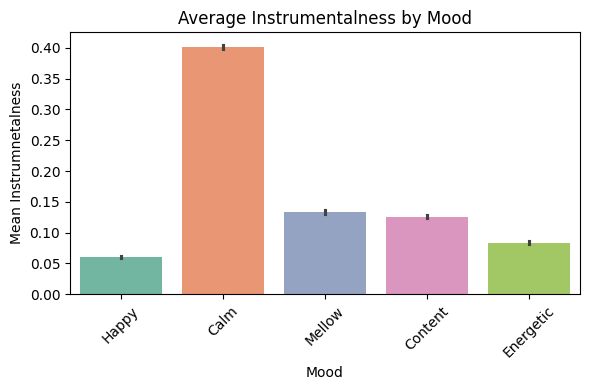

In [48]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='mood', y='instrumentalness', hue='mood', palette='Set2', legend=False)
plt.title('Average Instrumentalness by Mood')
plt.xlabel('Mood')
plt.ylabel('Mean Instrumnetalness')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

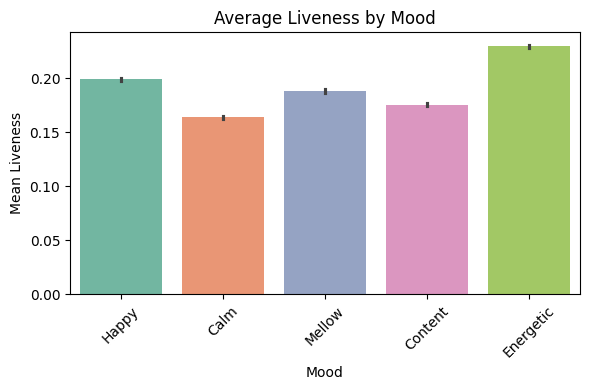

In [49]:
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='mood', y='liveness', hue='mood', palette='Set2', legend=False)
plt.title('Average Liveness by Mood')
plt.xlabel('Mood')
plt.ylabel('Mean Liveness')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The graphs above reinforce the insights observed in the radar chart while offering a clearer, more detailed view of each feature across clusters. The cluster labeled "Calm" exhibits the lowest danceability, whereas the other clusters show moderate to high levels. Although the average tempo appears fairly uniform across clusters in the bar graph, the radar chart reveals that "Mellow" has the lowest tempo, and "Energetic" the highest. The loudness bar plot aligns with expectations, confirming that "Calm" is the quietest cluster, while "Energetic" is the loudest. Similarly, the speechiness graph indicates that "Calm" has the lowest speech content, and "Mellow" the highest. The instrumentality bar plot highlights that "Calm" features the highest instrumental content, with the remaining clusters showing minimal levels. Lastly, the liveness graph supports the radar chart by showing "Energetic" as the cluster with the most live-like sound characteristics.

In conclusion, the labels "Calm," "Content," "Mellow," "Happy," and "Energetic" appear to accurately reflect the characteristics of their respective clusters. We feel confident in our labeling decisions.

### <font color='6e6e6e'>Possible interaction terms</font>

The plot below shows a smoothed interaction between tempo and average danceability, broken down by mood category. Each colored line represents a different mood and how danceability changes as tempo is increased.

We are looking at this to explore whether mood influences the relationship between tempo and danceability. The results show this to be pretty weak interaction, most lines follow a hump-shaped pattern, peaking around mid-range tempos and declining afterward. Since this happens across all moods, we can understand that tempo alone may be driving the danceability pattern, not mood. Additionally, the lines are noisy at low and high tempo ranges, especially for moods like Mellow and Energetic, which again shows that it is not a very meaningful trend. The slopes at the bottom reinforce this as most are near zero, meaning tempo doesn’t systematically increase or decrease danceability in a linear relationship per mood. This all indicates that this interaction is not likely to explain much additional variance.

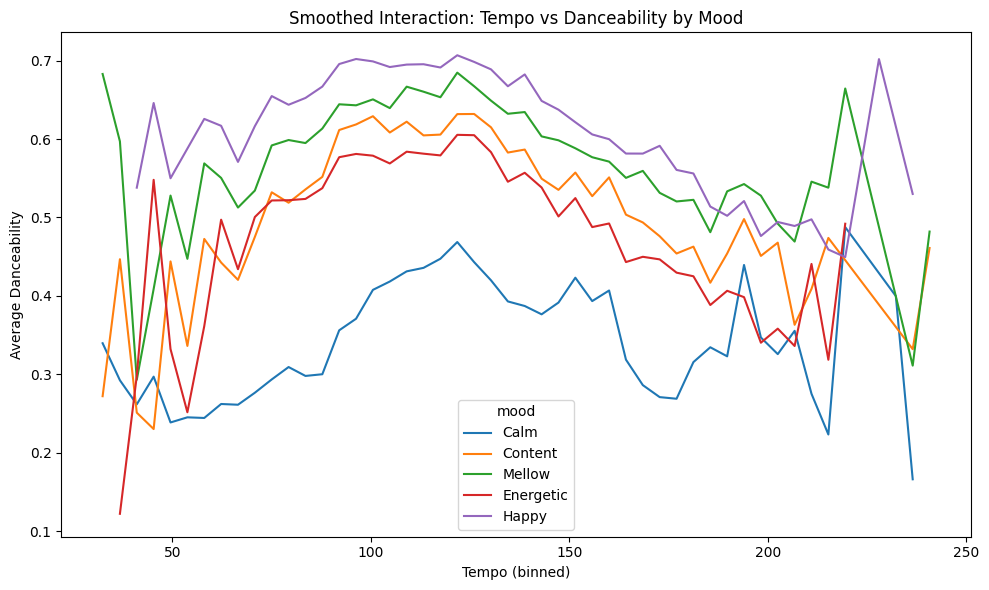

Slopes (tempo vs danceability) by mood:
Calm: 0.0010
Content: -0.0003
Energetic: -0.0013
Happy: -0.0012
Mellow: -0.0005


In [50]:
from numpy import polyfit
# Create binned tempo series (temporary)
tempo_bins = pd.cut(df['tempo'], bins=50)

# Group by bin and mood, compute mean danceability (without modifying df)
binned = (
    df
    .assign(tempo_bin=tempo_bins)  # temp column inside method chain
    .groupby(['tempo_bin', 'mood'], observed=True)['danceability']
    .mean()
    .reset_index()
)

# Compute midpoints from bin labels
binned['tempo'] = binned['tempo_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=binned, x='tempo', y='danceability', hue='mood')
plt.title("Smoothed Interaction: Tempo vs Danceability by Mood")
plt.xlabel("Tempo (binned)")
plt.ylabel("Average Danceability")
plt.tight_layout()
plt.show()

#  Calculate slopes per mood using original df
slopes_temp_dance = {}
for mood in df['mood'].unique():
    sub = df[df['mood'] == mood]
    slope, _ = polyfit(sub['tempo'], sub['danceability'], 1)
    slopes_temp_dance[mood] = slope

# Print slopes in numeric cluster order
print("Slopes (tempo vs danceability) by mood:")
for mood in sorted(slopes_temp_dance.keys()):
    print(f"{mood}: {slopes_temp_dance[mood]:.4f}")

The following plot explores the relationship between loudness and danceability, broken down by mood. Each line represents how average loudness varies as danceability increases for a given mood. The lines appear visually distinct and smooth, especially in the mid-to-high danceability ranges. Energetic and Happy tracks, for isntance, consistently maintain higher loudness levels across all levels of danceability, while Calm tracks remain significantly quieter even as danceability increases. This suggests that for the same danceability level, different moods lead to distinct loudness expectations, this is a sign there is a possible interaction here. Beyond this, the non-parallel lines reinforce that mood shifts the danceability-loudness relationship in more than just intercept as the shapes and elevations differ. So while the individual slopes are not very steep, this plot still shows a consistent and structured interaction effect, making it a an interaction we will inspect further in later steps. 

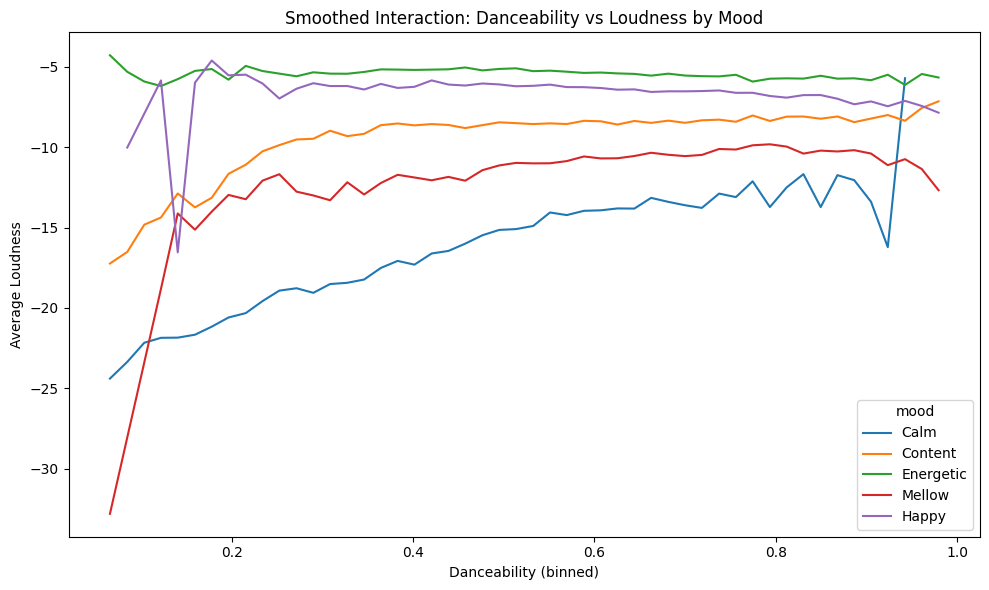


Slopes (danceability vs loudness) by mood:
Calm: 0.0010
Content: -0.0003
Energetic: -0.0013
Happy: -0.0012
Mellow: -0.0005


In [51]:
# GOOD INTERACTION

# Creating temporary binning for danceability
danceability_bins = pd.cut(df['danceability'], bins=50)

# Grouping by binned danceability and mood to get average loudness
danceability_grouped = (
    df
    .assign(danceability_bin=danceability_bins)
    .groupby(['danceability_bin', 'mood'], observed=True)['loudness']
    .mean()
    .reset_index()
)

# Computing midpoints of bins for plotting
danceability_grouped['danceability'] = danceability_grouped['danceability_bin'].apply(lambda x: x.mid)

# Plotting
plt.figure(figsize=(10, 6))
sns.lineplot(data=danceability_grouped, x='danceability', y='loudness', hue='mood')
plt.title("Smoothed Interaction: Danceability vs Loudness by Mood")
plt.xlabel("Danceability (binned)")
plt.ylabel("Average Loudness")
plt.tight_layout()
plt.show()

# Slope calculation per mood
slopes_dance_loud = {}
for mood in df['mood'].unique():
    sub = df[df['mood'] == mood]
    slope, _ = polyfit(sub['danceability'], sub['loudness'], 1)
    slopes_dance_loud[mood] = slope

# Printing slopes in sorted cluster order
print("\nSlopes (danceability vs loudness) by mood:")
for mood in sorted(slopes_temp_dance.keys()):
    print(f"{mood}: {slopes_temp_dance[mood]:.4f}")



The following plot shows the interaction between speechiness and tempo by mood. While the slopes dont show a very strong interaction, the visual divergence across moods is still compelling. The plot reveals that at higher levels of speechiness, the different moods begin to diverge in tempo. For example, Energetic and Happy moods show spikes in tempo as speechiness increases, while Calm, Mellow, and Content tend to flatten or decline. This suggests that high speechiness content interacts with mood to drive distinct tempo behaviors. Beyond this, the non-parallel, fluctuating lines in the higher speechiness range suggest that mood plays a role in how tempo responds to speechiness. This all indicates that it this could be an interaction worth further exploring in our later steps. 

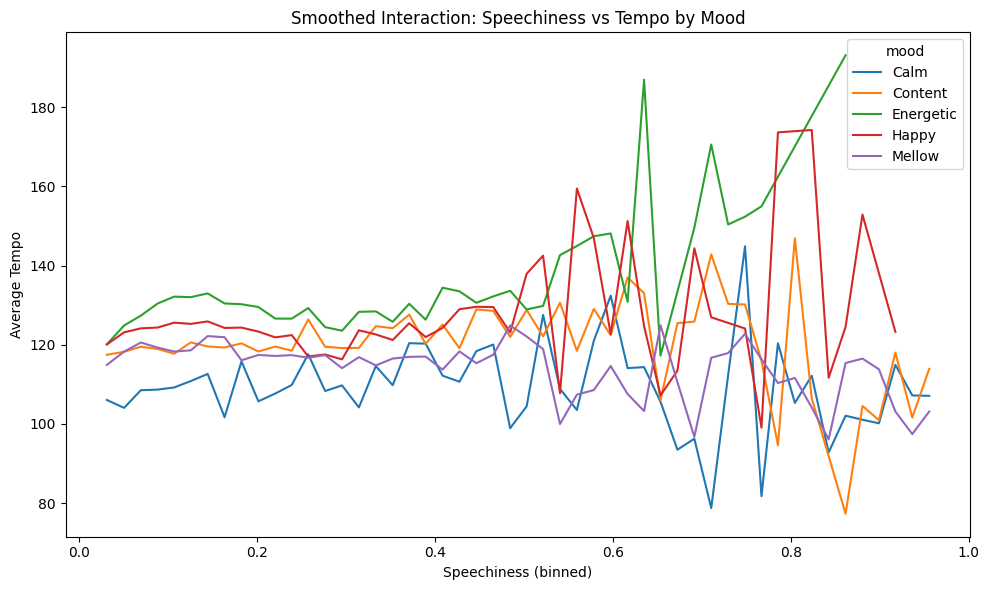


Slopes (speechiness vs tempo) by mood:
Calm: 0.0010
Content: -0.0003
Energetic: -0.0013
Happy: -0.0012
Mellow: -0.0005


In [52]:
## GOOD INTERACTION

# Create temporary binning for speechiness
speechiness_bins = pd.cut(df['speechiness'], bins=50)

# Group by binned speechiness and mood to get average tempo
speechiness_grouped = (
    df
    .assign(speechiness_bin=speechiness_bins)
    .groupby(['speechiness_bin', 'mood'], observed=True)['tempo']
    .mean()
    .reset_index()
)

# Compute midpoints of bins for plotting
speechiness_grouped['speechiness'] = speechiness_grouped['speechiness_bin'].apply(lambda x: x.mid)

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(data=speechiness_grouped, x='speechiness', y='tempo', hue='mood')
plt.title("Smoothed Interaction: Speechiness vs Tempo by Mood")
plt.xlabel("Speechiness (binned)")
plt.ylabel("Average Tempo")
plt.tight_layout()
plt.show()

# Slope calculation per mood
slopes_speech_tempo = {}
for mood in df['mood'].unique():
    sub = df[df['mood'] == mood]
    slope, _ = polyfit(sub['speechiness'], sub['tempo'], 1)
    slopes_speech_tempo[mood] = slope

# Print slopes in sorted cluster order
print("\nSlopes (speechiness vs tempo) by mood:")
for mood in sorted(slopes_temp_dance.keys()):
    print(f"{mood}: {slopes_temp_dance[mood]:.4f}")



### <font color='6e6e6e'>Conclusions</font>

After thoroughly exploring the audio features of each cluster, we were able to assign meaningful and descriptive mood labels: Happy, Calm, Content, Mellow, Energetic. This decision was guided by a combination of methods. First, we sampled songs from each cluster to subjectively assess their mood. Then, we supported our impressions with radar plots and distribution graphs that showed distinct trends, such as high energy and tempo for Energetic, or low loudness and speechiness for Calm. Finally, by exploring feature interactions like loudness vs. danceability or tempo vs. speechiness, we observed consistent internal structure within each cluster. Altogether, these insights validated that our cluster names were not arbitrary but grounded in both subjective listening and measurable patterns across the dataset.

# <font color='#3c3c3c'>Handling Missing values</font>

One row in the dataset contained a missing value (track name) and was dropped during preprocessing. Given the dataset’s large size, this removal will have no impact on the analysis or model performance. 

In general, missing values can pose significant issues in machine learning and data analysis. They can distort statistical summaries, bias model training, and reduce overall performance, especially if the missingness is not random. For example, missing values in key predictive features could lead to inaccurate relationships being learned or models making unreliable predictions. This is why it’s essential to handle missing data carefully through imputation, exclusion, or deeper investigation depending on the context and severity.

In [53]:
df.head()

,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,mood
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,Happy
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,Happy
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,Calm
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,Calm
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,Calm


In [54]:
df.dropna(inplace=True)

In [55]:
df = df.drop(columns=clustering_features)

# <font color='#3c3c3c'>Data Splitting</font>

In order to prepare our data for training and evaluation we applied a stratified train/validation/test split strategy. We did this because we wanted to ensure that the distribution of our target variable of mood is preserved  across all subsets. This is going to help in preventing bias, especially when we start dealing with class imbalance. We chose not to use random or time-based splits, as they could lead to uneven class distributions or are not applicable to non-temporal data like ours.

We began by splitting the data into two parts, a training set of 90% of our data and a validation/testing set of 5%. While this may seem unbalanced at first glance, our dataset is extremely large (over 200,000 samples), so even 5% yields a substantial number of samples for validation and testing. This allows us to maximize the amount of data used for training while still holding out enough examples for robust model tuning and evaluation.

We used stratification in both splits, to maintain a consistent class proportions across all subsets. This was essential to prevent bias and ensure that each mood class remained represented in the training, validation, and test sets.

As a result, we obtained:
- 200,738 samples for training
- 11,152 samples for validation
- 11,153 samples for testing

This split sets us up with a fair foundation for evaluating the models performance and ensuring that our results are able to generalize successfully beyond the training data. 

In [56]:
from sklearn.model_selection import train_test_split

In [57]:
y = df["mood"]
X = df.drop(columns=["mood"])

# first split 
X_train, X_other, y_train, y_other = train_test_split(
    X, y, test_size=0.1, stratify=y, random_state=42
)

#second split
X_val, X_test, y_val, y_test = train_test_split(
    X_other, y_other, test_size=0.5, stratify=y_other, random_state=42
)

print("Training Set:", X_train.shape, y_train.shape)
print("Validation Set:", X_val.shape, y_val.shape)
print("Test Set:", X_test.shape, y_test.shape)


Training Set: (200738, 15) (200738,)
Validation Set: (11152, 15) (11152,)
Test Set: (11153, 15) (11153,)


# <font color='#3c3c3c'>Creating New Features</font>

In this step, we improved our feature set by removing problematic columns as engineering some new interaction based features. First, we dropped a set of columns that would have added unnecessary and leaky data. Columns like track_name, track_id and artist__name are simply identifiers, they do not actually carry any predictive power for mood classification and would most likely just introduce noise into the model. 

We also chose to remove genre, popularity and dimensionality reduction outputs (pca1, pca2, umap1, umap2) because they were either derived from or highly correlated with our target. Genre, for instance, might seem intuitively useful but it can actually leak label-like information because it so closely correlates with the mood we are trying to predict, so in order to prevent this kind of hidden leakage, we excluded it from the final learning features. Lastly, we also removed mood_cluster to further prevent any data leakage from the clustering process used to create the target labels.

Next, based on insights we found during EDA, we created two new interaction features in order to further reflect deeper musical qualities that were not captured by individual variables alone. 
- Dance_loud: This feature is a combination of danceability and loudness, that highlights tracks that are both energetic and rhythmically engaging. It emphasizes songs that are not only loud but also highly danceable, often aligning with upbeat or intense moods.
- Speech_tempo: This feature is a product of speechiness and tempo. It is meant to capture fast-paced tracks with spoken-word characteristics, which may help distinguish genres like rap or hype tracks from more mellow ones.

These engineered features were created to provide the model with richer descriptions of musical mood as a way to boost performance and help the algorithm detect more abstract emotional patterns that are not fully captured within the original features included in the dataset.

In [58]:
# Saving track names to use later in testing 
X_test_meta = X_test[["track_name", "artist_name"]].reset_index(drop=True)

In [59]:
drop_cols = [
    'track_name',      
    'track_id',        
    'artist_name',     
    'genre',            
    'duration_ms',
    'popularity',
    'pca1', 'pca2',
    'umap1', 'umap2',
    'mood_cluster'
]

X_train = X_train.drop(columns=[col for col in drop_cols if col in X_train.columns])
X_test = X_test.drop(columns=[col for col in drop_cols if col in X_test.columns])

print("Dropped unnecessary and leaky columns.")

X_train['dance_loud'] = X_train['danceability'] * X_train['loudness']
X_test['dance_loud'] = X_test['danceability'] * X_test['loudness']

X_train['speech_tempo'] = X_train['speechiness'] * X_train['tempo']
X_test['speech_tempo'] = X_test['speechiness'] * X_test['tempo']



print("Created new interaction features.")

Dropped unnecessary and leaky columns.
Created new interaction features.


# <font color='#3c3c3c'>Encoding Categorical Variables</font>

Now that we have split the data, created interaction terms, and dropped unnecessary features,  we can move to encoding those features that can’t be interpreted. 

Encoding is an essential step when working with categorical data, as most machine learning models are designed to interpret only numerical values. Categorical variables must be transformed into a numerical format that retains as much meaningful information as possible. There are several encoding techniques available, including label encoding, one-hot encoding, and cyclical encoding. 

In our case, we explored the possibility of using cyclical encoding for the key feature, since musical keys have an underlying circular structure (e.g., A leads back to G#). However, we ultimately decided it would not contribute significantly to mood prediction and might overcomplicate the feature space. Instead, we applied label encoding to binary features and one-hot encoding to nominal features with no inherent order. This approach allows the model to interpret categorical data effectively without introducing unintended ordinal relationships or complexity. 

Finally, we used .align() to ensure consistent column structures across the training, validation, and test sets, which is especially important when working with large datasets where category combinations may vary.


As we can see in the graph above, the categorical features in our dataset are: “key”, “mode”, “time_signature”. 

In [60]:
X_train.head()

,danceability,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,dance_loud,speech_tempo
164001,0.778,0.000000,C#,0.1180,-8.044,Major,0.1100,127.983,4/4,-6.258232,14.078130
135550,0.672,0.000000,G#,0.0602,-5.305,Major,0.0423,97.501,4/4,-3.564960,4.124292
14433,0.751,0.000023,D,0.1330,-4.036,Major,0.0321,105.031,4/4,-3.031036,3.371495
79582,0.133,0.060900,D#,0.1300,-8.690,Minor,0.0440,90.566,4/4,-1.155770,3.984904
122153,0.763,0.000000,A,0.0693,-8.843,Minor,0.3290,90.032,4/4,-6.747209,29.620528


**mode**: We decided to use label encoding to encode this feature since it is a binary categorical feature. In this case, 0 will represent “Minor” and 1 will represent “Major”. 

**key**: For key, we initially thought it could make sense to use cyclical encoding since keys have order but then we realized that the model wouldn’t benefit from it to benefit the mood. Therefore, we simply decided to use one-hot encoding to avoid any unnecessary encoding. 

**time_signature**: This feature describes the number of beats per measure (e.g., 3/4, 4/4, 5/4). Again, we decided to use one-hot encoding to encode time signatures since there are a few types of time signatures and order is not important. 

Since we are handling a large dataset the number and names of columns might differ between X_train, X_val, and X_test, so we need to make sure the sets have similar shapes. To make sure the column structure matches we used .align(). 

In [61]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

X_train['mode'] = le.fit_transform(X_train['mode'])
X_val['mode'] = le.transform(X_val['mode'])
X_test['mode'] = le.transform(X_test['mode'])

X_train = pd.get_dummies(X_train, columns=['key', 'time_signature'], drop_first=True)
X_val = pd.get_dummies(X_val, columns=['key', 'time_signature'], drop_first=True)
X_test = pd.get_dummies(X_test, columns=['key', 'time_signature'], drop_first=True)

X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [62]:
print(X_train.columns)

Index(['danceability', 'instrumentalness', 'liveness', 'loudness', 'mode',
       'speechiness', 'tempo', 'dance_loud', 'speech_tempo', 'key_A#', 'key_B',
       'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#',
       'key_G', 'key_G#', 'time_signature_1/4', 'time_signature_3/4',
       'time_signature_4/4', 'time_signature_5/4'],
      dtype='object')


# <font color='#3c3c3c'>Feature Scaling</font>

The next step we undertook was to perform scaling on our continuous features to standardize the ranges. This is a crucial step in preprocessing, as without it features with larger values may dominate during learning, which would in turn lead to biased predictions.

Standardization and normalization are both very common feature scaling techniques, and are very important in ensuring that numerical variables contribute equally to a model. However, it is very important to understand their differences before choosing which one to use. Ultimately, the choice between them mainly depends on the dataset being used.

Standardization:
- Transforms the data to have a mean of 0 and std deviation of 1
- Keeps the original shape of the distribution (just scales it)

Normalization:
- Rescales data between 0 and 1
- Works well when data has no strong outliers

With these differences in mind, we chose to use standardization, specifically using StandardScaler. This method is widely used in machine learning pipelines, mainly because:
- It preserves the distribution shape of the data, unlike normalization methods 
- It keeps outliers visible, rather than compressing them into narrow ranges

We originally considered MinMax scaling as an option too, but decided against it for a few reasons:
- It is too sensitive to outliers, as a single extreme value stretches the entire scale
- It is less interpretable, since it removes info about the spread and standard deviation of features
- It is more suited to other tasks such as image processing, where pixel values for example naturally lie in a fixed range

Ultimately, standardization provided a more balanced, robust, and interpretable transformation for our dataset and model selection.


In [63]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [64]:
# verify transformation
print("First few rows of standardized X_train:")
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print(X_train_scaled_df.head())

First few rows of standardized X_train:
   danceability  instrumentalness  liveness  loudness      mode  speechiness  \
0      1.185638         -0.502769 -0.454711  0.237054 -0.733709     0.212658   
1      0.623833         -0.502769 -0.806276  0.691780 -0.733709    -0.472424   
2      1.042537         -0.502694 -0.363475  0.902459 -0.733709    -0.575641   
3     -2.232896         -0.304774 -0.381722  0.129805  1.362939    -0.455221   
4      1.106138         -0.502769 -0.750926  0.104404  1.362939     2.428802   

      tempo  dance_loud  speech_tempo   key_A#  ...    key_D#     key_E  \
0  0.307942   -0.589646      0.258926 -0.26554  ... -0.181955 -0.283833   
1 -0.683218    0.456843     -0.514945 -0.26554  ... -0.181955 -0.283833   
2 -0.438371    0.664303     -0.573472 -0.26554  ... -0.181955 -0.283833   
3 -0.908719    1.392951     -0.525782 -0.26554  ...  5.495854 -0.283833   
4 -0.926082   -0.779642      1.467285 -0.26554  ... -0.181955 -0.283833   

      key_F    key_F#     ke

# <font color='#3c3c3c'>Adressing Class Imbalance</font>

After performing feature scaling, we are now going to address the class imbalance problem in our mood classification, which is very evident from the initial distribution plot. The count plot revealed that some mood clusters (3 and 4) were significantly underrepresented in comparison to the other two. It is essential to deal with this imbalance because it can bias the models toward the majority classes, essentially leading to a poor generalization and misclassification of the minority classes. 

In order to mitigate this, we applied SMOTE. This approach generates synthetic examples of the minority classes by interpolating between existing ones. We applied this to the training set in order to avoid leakage. After applying SMOTE, all the clusters had an equal representation of 44,448 samples each. This will ensure that our models are not only accurate but fair and generalize across all mood categories. 

A different way to deal with class imbalance could have been to remove examples from our overrepresented classes in order to achieve a balanced dataset. While this would have been simpler and would have reduced training time, it would also involve losing valuable data, which could have hurt the performance  especially since our data is as large and rich as it is. We chose to not use this technique in order to not discard potentially useful information about the more common moods, especially because musical characteristics are nuanced and varied. We chose SMOTE because it strikes a balance between preserving the diversity of our data while still achieving class balance.

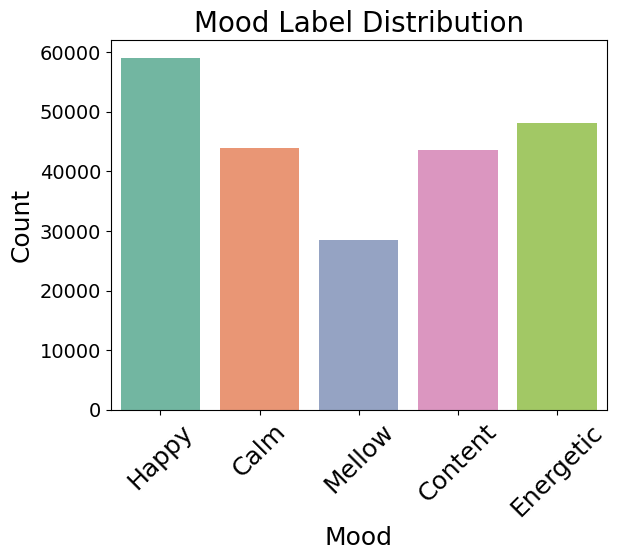

mood
Happy        0.264689
Energetic    0.215618
Calm         0.197114
Content      0.195066
Mellow       0.127514
Name: proportion, dtype: float64


In [65]:
sns.countplot(x='mood', hue='mood', data=df, palette='Set2', legend=False)

plt.title("Mood Label Distribution", fontsize=20)
plt.xlabel("Mood", fontsize=18)
plt.ylabel("Count", fontsize=18)

plt.xticks(rotation=45, fontsize=18)
plt.yticks(fontsize=14)

plt.show()

print(df['mood'].value_counts(normalize=True))

In [66]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

In [67]:
# from imblearn.combine import SMOTEENN

# smote_enn = SMOTEENN(random_state=42)
#X_train_resampled, y_train_resampled = smote_enn.fit_resample(X_train_scaled, y_train)

In [68]:
print("After Resampling (SMOTE):")
print(pd.Series(y_train_resampled).value_counts())
print(pd.Series(y_train_resampled).value_counts(normalize=True))

After Resampling (SMOTE):
mood
Content      53133
Happy        53133
Calm         53133
Mellow       53133
Energetic    53133
Name: count, dtype: int64
mood
Content      0.2
Happy        0.2
Calm         0.2
Mellow       0.2
Energetic    0.2
Name: proportion, dtype: float64


We also experimented with SMOTE+ENN (Edited Nearest Neighbors) to see if cleaning ambiguous samples would improve performance. We plotted the F1 scores we got from training the validation set for the Random Forest model. The bar plot compares the F1 scores for each mood cluster using the two different resampling strategies (SMOTE+ENN and just SMOTE). While SMOTE+ENN showed a slight improvement for the “Content” and “Mellow” clusters, it underperformed significantly in the other categories—especially for “Calm,” “Energetic,” and “Happy.” This suggest that ENN may have removed too many borderline but valid and useful samples that the model still should learn from. In conclusion, using just SMOTE preserved more data and consistently gave us better accuracy and class balance, making it the better choice for our model.

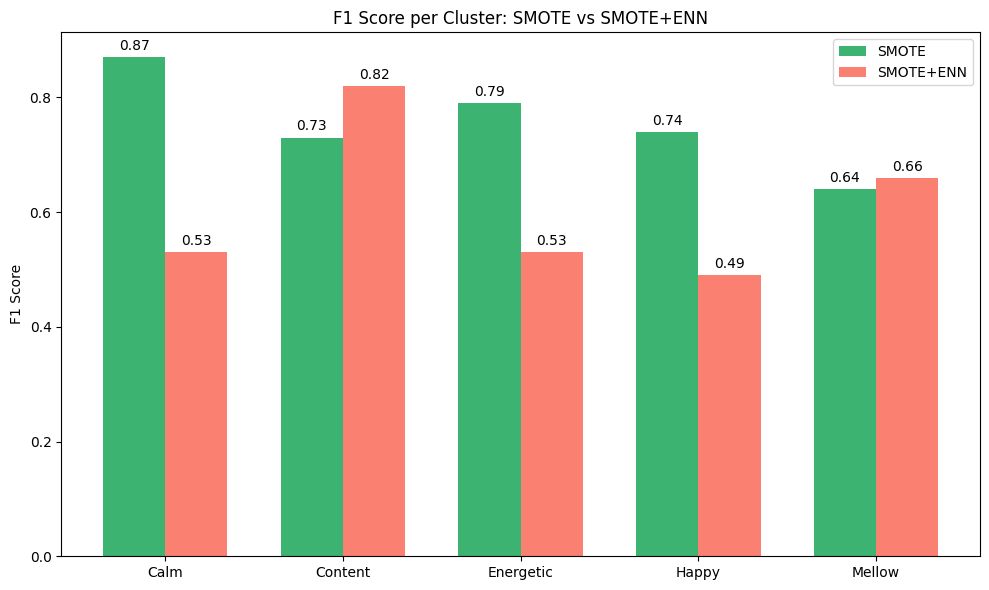

In [69]:
# Cluster labels
clusters = ['Calm', 'Content', 'Energetic', 'Happy', 'Mellow']

# Real SMOTE F1-scores 
f1_smote = [0.87, 0.73, 0.79, 0.74, 0.64]  

# SMOTEENN F1-scores 
f1_smoteenn = [0.53, 0.82, 0.53, 0.49, 0.66]  

x = np.arange(len(clusters))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10,6))
rects1 = ax.bar(x - width/2, f1_smote, width, label='SMOTE', color='mediumseagreen')
rects2 = ax.bar(x + width/2, f1_smoteenn, width, label='SMOTE+ENN', color='salmon')

# Add labels, title, legend
ax.set_ylabel('F1 Score')
ax.set_title('F1 Score per Cluster: SMOTE vs SMOTE+ENN')
ax.set_xticks(x)
ax.set_xticklabels(clusters)
ax.legend()

# Annotate bars with values
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3), textcoords="offset points", ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# <font color='#3c3c3c'>Feature Selection</font>

### <font color='6e6e6e'>Low variance features</font>

Features with low variance are often disregarded due to the little information it provides to the model to distinguish between classes. For example, if nearly every song has the same value for a given feature, that feature is unlikely to help our model learn meaningful patterns. To handle this, we decided that those features with a variance lower than 0.01 should be flagged as potential unnecessary features.
The results show that there are no features that have a low variance. This means that we have to further analyze and use different strategies to determine which features to drop. 

In [70]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_resampled)

high_variance_mask = selector.get_support()

# Applying the "mask" to all splits 
X_train_high_variance = X_train_resampled[:, high_variance_mask]
X_val_high_variance = X_val_scaled[:, high_variance_mask]
X_test_high_variance = X_test_scaled[:, high_variance_mask]

selected_features = X_train.columns[high_variance_mask]
print("Selected features after Variance Threshold:\n", selected_features.tolist())

dropped_features = X_train.columns[~high_variance_mask]
print("\nDropped features (variance < 0.01):\n", dropped_features.tolist())

Selected features after Variance Threshold:
 ['danceability', 'instrumentalness', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'dance_loud', 'speech_tempo', 'key_A#', 'key_B', 'key_C', 'key_C#', 'key_D', 'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#', 'time_signature_1/4', 'time_signature_3/4', 'time_signature_4/4', 'time_signature_5/4']

Dropped features (variance < 0.01):
 []


### <font color='6e6e6e'>Highly correlated features</font>

The following correlation check is identifying pairs of features with a high Pearson correlation coefficient (for us any correlation above 0.7).  This is useful as it helps us catch redundancy in our dataset that is going to hinder the final performance instead of help it. From the results we can see that two highly correlated feature pairs were flagged:

speechiness and speech_tempo: 0.93
These have a very strong positive correlation, suggesting that these two features essentially convey the same information. This is logical as speech_tempo was made from speechiness. It would likely be redundant to include both in the model, since they could inflate variance or reduce generalization. We will likely consider dropping one of these in the future in order to ensure we do not include this redundancy.

time_signature_3/4 and time_signature_4/4: 0.87
This is also a very high postive correlation, but once again it is expected since due to our use of one-hot encoding for the categorical features, they are inversely related (mutually exclusive). These time_signature columns are collinear and should be reduced to avoid noise and instability. We will also consider dropping one of these to guarantee better results. 

This check confirmed that some features are too closely related, and indicates that we need to consider removing or simplifying the redundant ones. Fixing this will result in a cleaner, more stable model.

In [71]:
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X_train.columns)

corr_matrix = X_train_resampled_df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.7
high_corr_pairs = [(col1, col2, upper.loc[col1, col2])
                   for col1 in upper.columns
                   for col2 in upper.index
                   if upper.loc[col1, col2] > threshold]

print("Highly correlated feature pairs (>|0.7|):")
for col1, col2, corr_val in high_corr_pairs:
    print(f"{col1} and {col2}: {corr_val:.2f}")

Highly correlated feature pairs (>|0.7|):
speechiness and speech_tempo: 0.93
time_signature_3/4 and time_signature_4/4: 0.87


### <font color='6e6e6e'>VIF analysis</font>

We are also checking the Variance Inflation Factor (VIF) because it will help us assess multicollinearity in our dataset. Getting a high multicollinearity can distort model coefficients and reduce interpretability, which is why we want to ensure the final features we use dont have this high value. In this output, we can observe extremely high VIF values for the one-hot encoded time_signature variables. Time_signature_4/4 has a VIF of over 3900, while others like 3/4, 5/4, and 1/4 also exceed values of 300 and even 600. These are far above the typical  thresholds of 5 or 10, and indicate severe multicollinearity due to redundant encoding. This suggests that only one of these should be kept. 

Beyond the time signatures, a few other features have a somewhat high VIP. Speech_tempo and speechiness show VIFs of around 14 and 13, respectively, suggesting they may be encoding similar information or maybe are highly correlated with another variable in the dataset. Dance_loud and danceability both fall in the 4–5 range, and loudness is at around 6. These indicats a potential overlap or redundancy which makes logical sense as dance_loud was made from the danceability variable. The rest of the features all have low VIFs (generally below 2), meaning that they are safe to keep as they do not introduce significant multicollinearity. We will take these results into account when deciding what to we should drop going foward. 

In [72]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_temp = X_train_resampled_df.copy()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_temp.columns
vif_data["VIF"] = [variance_inflation_factor(X_temp.values, i) for i in range(X_temp.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

               Feature          VIF
22  time_signature_4/4  3916.037798
21  time_signature_3/4  3132.721423
23  time_signature_5/4   658.474740
20  time_signature_1/4   341.967953
8         speech_tempo    14.433575
5          speechiness    13.438519
3             loudness     6.683321
7           dance_loud     5.507582
0         danceability     4.655106
11               key_C     1.993860
6                tempo     1.938543
18               key_G     1.934653
13               key_D     1.856727
12              key_C#     1.789002
16               key_F     1.741907
15               key_E     1.634617
10               key_B     1.631830
9               key_A#     1.565711
19              key_G#     1.558635
17              key_F#     1.528263
1     instrumentalness     1.461483
14              key_D#     1.301921
4                 mode     1.080455
2             liveness     1.049840


### <font color='6e6e6e'>Conclusions</font>

Based on the results from the checks above (multicollinearity and correlation) we chose to drop the following features: 'time_signature_4/4', 'speech_tempo', 'dance_loud'. These were the ones that showed an extremely high Variance Inflation Factor (VIF) or strong pairwise correlations. 
By removing them in all three datasets (X_train, X_val, and X_test), we are improving our feature set by reducing redundancy and potential overfitting.


In [73]:
to_drop = ['time_signature_4/4', 'speech_tempo', 'dance_loud']

X_train_reduced = X_train_resampled_df.drop(columns=to_drop)
X_val_reduced = pd.DataFrame(X_val_scaled, columns=X_train_resampled_df.columns).drop(columns=to_drop)
X_test_reduced = pd.DataFrame(X_test_scaled, columns=X_train_resampled_df.columns).drop(columns=to_drop)

# printing the dataset to check the correct columns were dropped
print(X_train_reduced.head())

   danceability  instrumentalness  liveness  loudness      mode  speechiness  \
0      1.185638         -0.502769 -0.454711  0.237054 -0.733709     0.212658   
1      0.623833         -0.502769 -0.806276  0.691780 -0.733709    -0.472424   
2      1.042537         -0.502694 -0.363475  0.902459 -0.733709    -0.575641   
3     -2.232896         -0.304774 -0.381722  0.129805  1.362939    -0.455221   
4      1.106138         -0.502769 -0.750926  0.104404  1.362939     2.428802   

      tempo   key_A#     key_B     key_C  ...     key_D    key_D#     key_E  \
0  0.307942 -0.26554 -0.287678 -0.371444  ... -0.340340 -0.181955 -0.283833   
1 -0.683218 -0.26554 -0.287678 -0.371444  ... -0.340340 -0.181955 -0.283833   
2 -0.438371 -0.26554 -0.287678 -0.371444  ...  2.938242 -0.181955 -0.283833   
3 -0.908719 -0.26554 -0.287678 -0.371444  ... -0.340340  5.495854 -0.283833   
4 -0.926082 -0.26554 -0.287678 -0.371444  ... -0.340340 -0.181955 -0.283833   

      key_F    key_F#     key_G    key_G#  t

We are now once again checking the updated VIF (Variance Inflation Factor) in order to confirm that the multicollinearity issue has been addressed after dropping the problematic features. As we can see, all the remaining features now have VIF values well below the commonly used threshold of 5, which is a good sign and means we can move foward confidently.

In [74]:
# quickly checking the VIF now that we dropped some features 
X_temp = X_train_reduced.copy()

vif_data = pd.DataFrame()
vif_data["Feature"] = X_temp.columns
vif_data["VIF"] = [variance_inflation_factor(X_temp.values, i) for i in range(X_temp.shape[1])]

print(vif_data.sort_values(by="VIF", ascending=False))

               Feature       VIF
9                key_C  1.993752
16               key_G  1.934646
11               key_D  1.856644
10              key_C#  1.784578
14               key_F  1.741871
3             loudness  1.679748
13               key_E  1.634604
8                key_B  1.631356
7               key_A#  1.565497
17              key_G#  1.557417
15              key_F#  1.527668
1     instrumentalness  1.454233
0         danceability  1.452149
12              key_D#  1.301848
19  time_signature_3/4  1.127195
5          speechiness  1.122259
4                 mode  1.076387
6                tempo  1.067532
2             liveness  1.048722
20  time_signature_5/4  1.038355
18  time_signature_1/4  1.022360


The VIF values now are all below 5, which means there is no multicollinearity. This is exactly what we were looking for and it confirms we don’t have to drop any more features. 

# <font color='#3c3c3c'>Baseline</font>

### <font color='6e6e6e'>Metrics used</font>

Although we balanced the training data using SMOTE to help models learn each mood class more equally, our validation and test sets remain imbalanced. They are reflecting the real-world distribution of moods in music.

So because of this, using accuracy alone to evaluate the performance of the model is not enough. Because the model can achieve high accuracy by favoring the majority classes, while still failing to recognize underrepresented moods.

Therefore, we use additional metrics:
- Macro F1 Score: Averages F1 across all classes equally; it highlights performance on minority classes.
- Per class F1 Scores: Allow us to directly assess how well each individual mood category is being predicted.
- Precision & Recall: Help understand whether certain moods are over or under-predicted. This is visualized through a Confusion Matrix.

These metrics help us evaluate not just how often the model is right, but also how fairly it performs across all moods, which is essential for a mood-based recommendation system.

### <font color='6e6e6e'>Majority Class Predictor</font>

To establish a basic point of comparison, we implemented a majority class predictor using DummyClassifier with the "most_frequent" strategy. This classifier always predicts the most common class in the training set, ignoring all feature input. In our case, that class was “Calm.” While simplistic, this baseline helps contextualize how much value more complex models add over a naïve, frequency-based guess.

As expected, the DummyClassifier achieved a validation accuracy of only 19.72%, corresponding exactly to the proportion of the majority class in the test set. The confusion matrix confirms that every single prediction was “Calm,” regardless of the true label. This resulted in a precision, recall, and F1 score of 0.00 for all other mood categories, making it a highly biased and uninformative model. The ROC curve further reinforces this, all classes have an AUC of 0.50, indicating the classifier is no better than random guessing in terms of probability ranking.

Overall, this baseline highlights the importance of using real models for mood classification. Although the DummyClassifier provides high accuracy on one class, it fails completely at recognizing any mood diversity, making it unsuitable for any application where fairness and coverage across emotional states matter.

Training Accuracy (Majority Class Predictor): 0.2000
Validation Accuracy (Majority Class Predictor): 0.1972

Classification Report (Validation - Majority Class Predictor):
              precision    recall  f1-score   support

        Calm       0.20      1.00      0.33      2199
     Content       0.00      0.00      0.00      2175
   Energetic       0.00      0.00      0.00      2405
       Happy       0.00      0.00      0.00      2952
      Mellow       0.00      0.00      0.00      1422

    accuracy                           0.20     11153
   macro avg       0.04      0.20      0.07     11153
weighted avg       0.04      0.20      0.06     11153



/Users/gabyvega/ExpenseManagement/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/gabyvega/ExpenseManagement/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/Users/gabyvega/ExpenseManagement/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



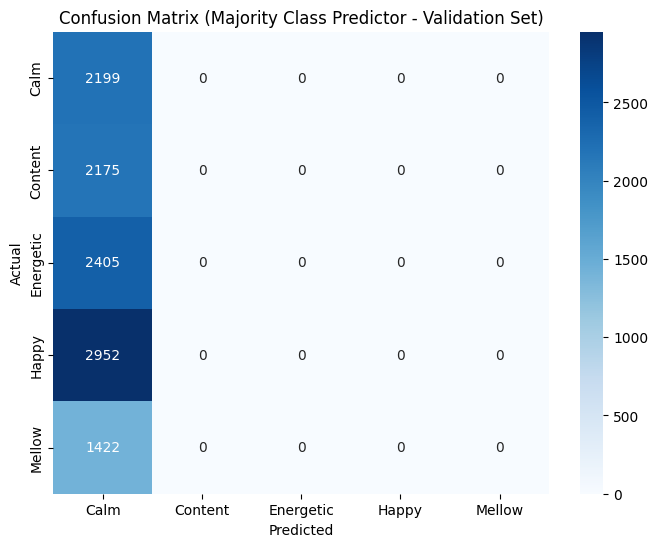

In [75]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score

# predicting the most common class in training 
dummy_clf = DummyClassifier(strategy="most_frequent", random_state=42)
dummy_clf.fit(X_train_resampled, y_train_resampled)

y_train_pred_dummy = dummy_clf.predict(X_train_resampled)
y_test_pred_dummy = dummy_clf.predict(X_test_scaled)

# Training Accuracy Results 
train_accuracy = accuracy_score(y_train_resampled, y_train_pred_dummy)
print(f"Training Accuracy (Majority Class Predictor): {train_accuracy:.4f}")

# Validation Accuracy Results 
val_accuracy = accuracy_score(y_test, y_test_pred_dummy)
print(f"Validation Accuracy (Majority Class Predictor): {val_accuracy:.4f}")

print("\nClassification Report (Validation - Majority Class Predictor):")
print(classification_report(y_test, y_test_pred_dummy))


conf_matrix = confusion_matrix(y_test, y_test_pred_dummy)

# confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=dummy_clf.classes_, yticklabels=dummy_clf.classes_)
plt.title("Confusion Matrix (Majority Class Predictor - Validation Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

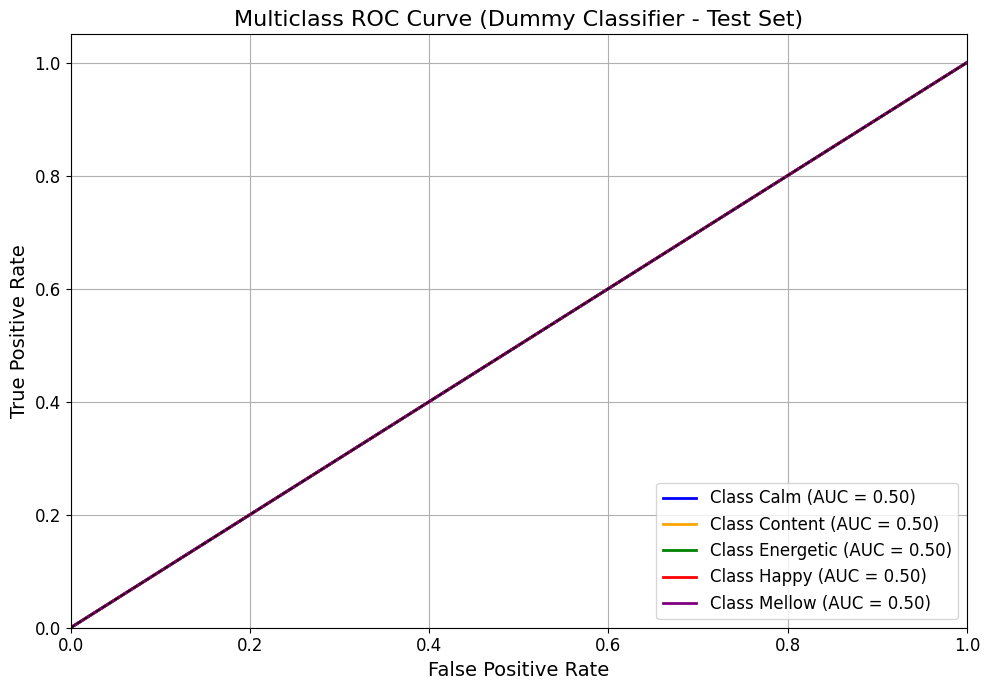

In [76]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# predicting class probabilities with DummyClassifier
y_score = dummy_clf.predict_proba(X_test_scaled)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

#  ROC curves
plt.figure(figsize=(10, 7))
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multiclass ROC Curve (Dummy Classifier - Test Set)', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


### <font color='6e6e6e'>Logistic Regression</font>

The results from the logistic regression model highlight several evident limitations. With a validation accuracy of just 53.75%, the model performs moderately better than random guessing for a five-class classification task, but still not well. While it performed well on Cluster 0 (Calm) with a high F1 score of 0.80, it struggled significantly on Cluster 1 (Content) and Cluster 4 (Mellow), with F1 scores of 0.36 and 0.40, respectively. This imbalance is a strong indication that the model struggles to generalize across all categories. In fact, most classes show a noticeable discrepancy between precision and recall, which means the model is often either too hesitant or too aggressive in its predictions. The overall macro F1 score was 0.527, further emphasizing the model's uneven performance across classes.

These results are not surprising given that logistic regression is a linear model, and our task, classifying moods based on audio features, is inherently non-linear and complex. Logistic regression does not accurately capture feature interactions or non linear decision boundaries, making it a poor fit for a dataset like this, especially when the classes are not linearly separable. Besides this, imbalanced class distributions further reduce its effectiveness, since logistic regression does not have built-in mechanisms to handle imbalance unless explicitly adjusted.

In the context of this project, these logistic regression results are useful only as a baseline. They demonstrate the need for more powerful models, such as Random Forests or Gradient Boosting, which can better handle feature complexity and class imbalance. Its poor performance here justifies moving to more sophisticated models that are better suited to the nature of the data and the task.

 Logistic Regression Baseline Results
Training Accuracy:   0.5322
Validation Accuracy: 0.5375
Macro F1 Score:      0.5270
Weighted F1 Score:   0.5345

 Validation Classification Report:
              precision    recall  f1-score   support

        Calm       0.81      0.80      0.80      2198
     Content       0.41      0.31      0.36      2176
   Energetic       0.55      0.64      0.59      2404
       Happy       0.51      0.46      0.48      2952
      Mellow       0.35      0.46      0.40      1422

    accuracy                           0.54     11152
   macro avg       0.53      0.53      0.53     11152
weighted avg       0.54      0.54      0.53     11152



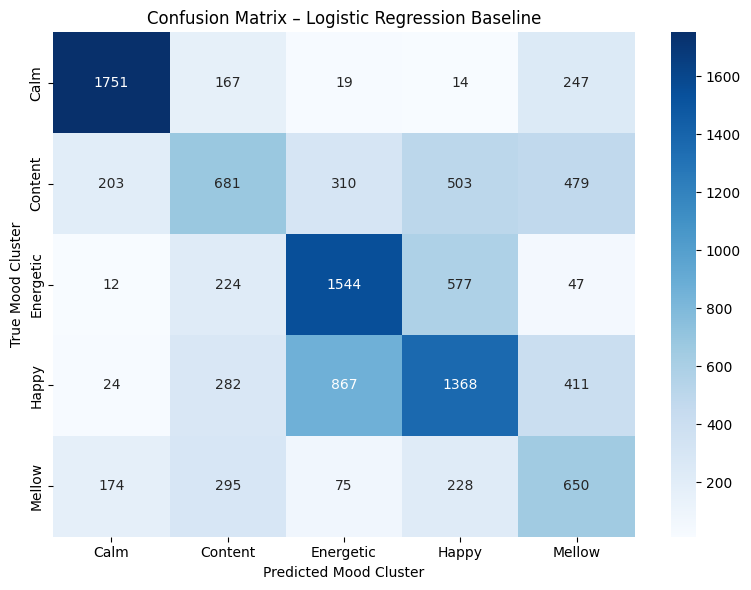

In [77]:
from sklearn.linear_model import LogisticRegression

# Training logistic regression with softmax AND class balancing
lr = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='lbfgs',
    class_weight='balanced'
)
lr.fit(X_train_reduced, y_train_resampled)

# training set
y_train_pred = lr.predict(X_train_reduced)
train_acc = accuracy_score(y_train_resampled, y_train_pred)

# validation set
y_val_pred = lr.predict(X_val_reduced)
val_acc = accuracy_score(y_val, y_val_pred)

# F1 scores
macro_f1 = f1_score(y_val, y_val_pred, average='macro')
weighted_f1 = f1_score(y_val, y_val_pred, average='weighted')


print(f" Logistic Regression Baseline Results")
print(f"Training Accuracy:   {train_acc:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Macro F1 Score:      {macro_f1:.4f}")
print(f"Weighted F1 Score:   {weighted_f1:.4f}")


print("\n Validation Classification Report:")
print(classification_report(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred)
confusion_labels = np.unique(y_val)

# Confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=confusion_labels, yticklabels=confusion_labels)
plt.title("Confusion Matrix – Logistic Regression Baseline")
plt.xlabel("Predicted Mood Cluster")
plt.ylabel("True Mood Cluster")
plt.tight_layout()
plt.show()

### <font color='6e6e6e'>Shuffle tests</font>

In order to ensure the integrity of our results and rule out data leakage, we conducted two diagnostic tests: target shuffling and feature shuffling. These tests are basically designed to validate that the model is actually learning meaningful relationships between the input features and the target labels, not just memorizing patterns that could arise from accidental leakage or randomness.

In the target shuffling test, we randomly permuted the mood labels while keeping the features unchanged. This disrupts any real association between the features and the target. If the model still performs well after this shuffle, it would suggest that it was not learning legitimate signals from the data, but instead possibly memorizing noise or being affected by some form of leakage. However, in our results, the validation accuracy dropped sharply from 0.5375 to 0.1738, confirming that the original model's performance was based on actual signal in the data.

In addition, the feature shuffling test randomly permutes the values in the feature matrix while keeping the target labels fixed. This is meant to break any true structure or relationships present in the features. After running this test, the model's accuracy fell to 0.3008, once again showing that the original features held real predictive value and were not simply noise.

Together, these results offer strong evidence that our model is not learning by accident or data leakage. The significant drop in performance after shuffling both the target and features reassures us that the model is capturing valid patterns and is not suffering from data leakage.

=== Original Model ===
Validation Accuracy: 0.5375

Classification Report:
              precision    recall  f1-score   support

        Calm       0.81      0.80      0.80      2198
     Content       0.41      0.31      0.36      2176
   Energetic       0.55      0.64      0.59      2404
       Happy       0.51      0.46      0.48      2952
      Mellow       0.35      0.46      0.40      1422

    accuracy                           0.54     11152
   macro avg       0.53      0.53      0.53     11152
weighted avg       0.54      0.54      0.53     11152



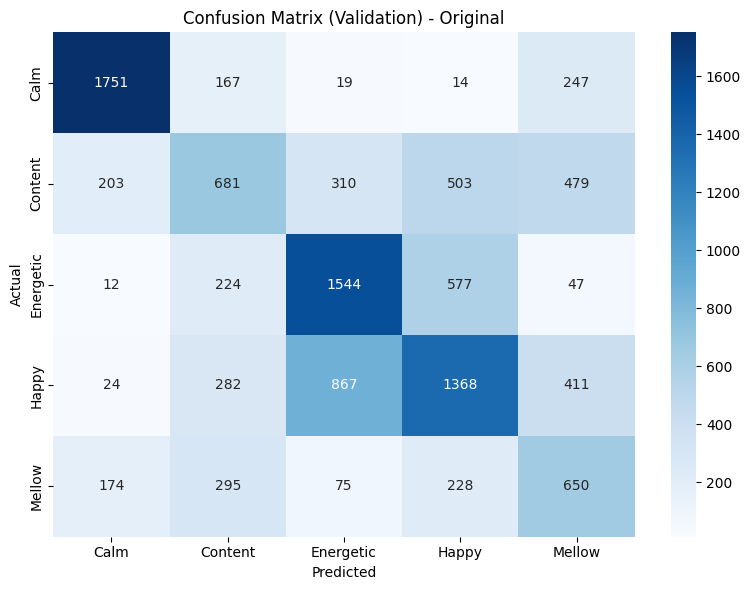


=== Shuffle Test 1: Random Target Variable ===
Validation Accuracy: 0.1738

Classification Report:
              precision    recall  f1-score   support

        Calm       0.13      0.17      0.15      2198
     Content       0.17      0.15      0.16      2176
   Energetic       0.13      0.11      0.12      2404
       Happy       0.29      0.25      0.27      2952
      Mellow       0.13      0.17      0.14      1422

    accuracy                           0.17     11152
   macro avg       0.17      0.17      0.17     11152
weighted avg       0.18      0.17      0.18     11152



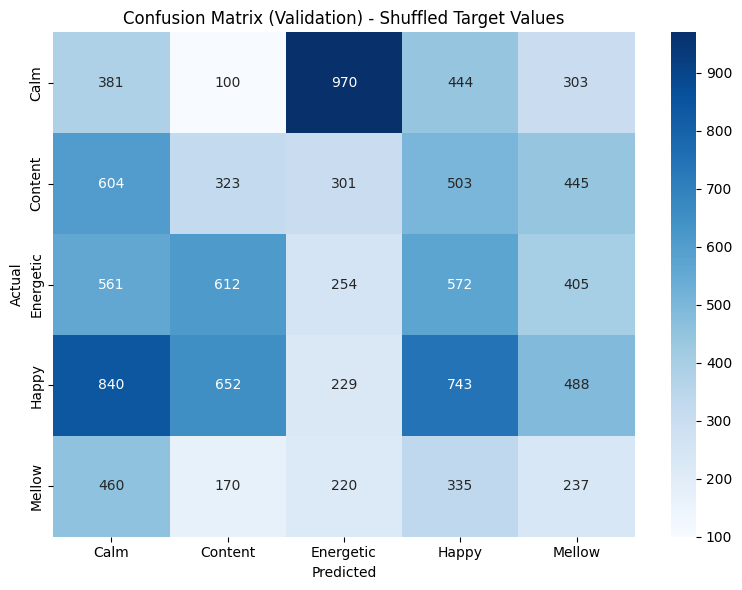


=== Shuffle Test 2: Shuffled Features ===
Validation Accuracy: 0.3008

Classification Report:
              precision    recall  f1-score   support

        Calm       0.54      0.54      0.54      2198
     Content       0.21      0.10      0.14      2176
   Energetic       0.28      0.29      0.28      2404
       Happy       0.35      0.27      0.30      2952
      Mellow       0.15      0.33      0.20      1422

    accuracy                           0.30     11152
   macro avg       0.30      0.30      0.29     11152
weighted avg       0.32      0.30      0.30     11152



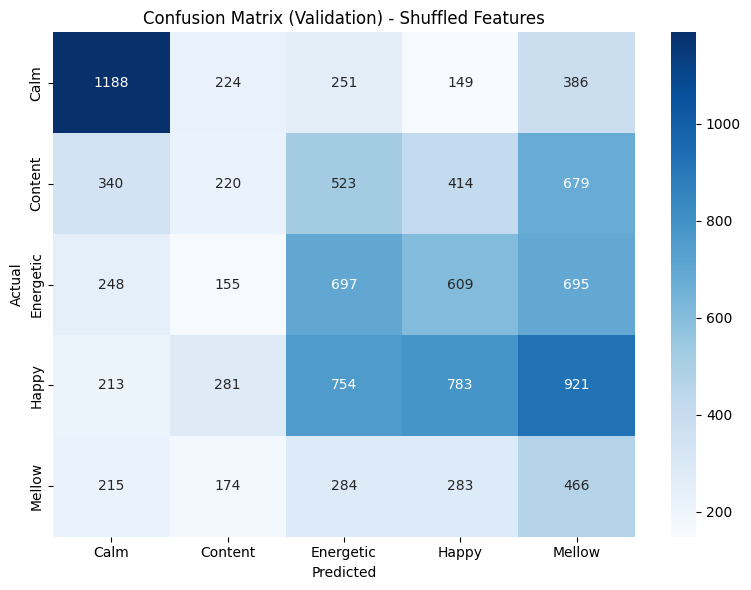


=== Data Leakage Test Summary ===
Original Model Accuracy: 0.5375
Shuffled Target Values Accuracy: 0.1738
Shuffled Features Accuracy: 0.3008

PASSED: Model performance is significantly worse with shuffled targets.
This suggests the model is learning real patterns rather than memorizing data.

PASSED: Model performance drops with shuffled features.
This suggests the features have meaningful relationships with the target.


In [78]:
def evaluate_model(X_train, y_train, X_val, y_val, title_suffix=""):
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    
    y_val_pred = lr.predict(X_val)
    
    val_acc = accuracy_score(y_val, y_val_pred)
    print(f"Validation Accuracy: {val_acc:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred))
    
    cm = confusion_matrix(y_val, y_val_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=confusion_labels, yticklabels=confusion_labels)
    plt.title(f"Confusion Matrix (Validation) {title_suffix}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()
    
    return val_acc

# first shuffle: shuffling target 
print("=== Original Model ===")
original_acc = evaluate_model(X_train_reduced, y_train_resampled, X_val_reduced, y_val, "- Original")

print("\n=== Shuffle Test 1: Random Target Variable ===")
np.random.seed(42)
y_train_shuffled = np.random.permutation(y_train_resampled)

shuffled_targets_acc = evaluate_model(
    X_train_reduced, y_train_shuffled, X_val_reduced, y_val, 
    "- Shuffled Target Values"
)

# second shuffle: shuffling features 
print("\n=== Shuffle Test 2: Shuffled Features ===")
X_train_shuffled_features = X_train_reduced.copy()
if isinstance(X_train_shuffled_features, pd.DataFrame):
    for col in X_train_shuffled_features.columns:
        X_train_shuffled_features[col] = np.random.permutation(X_train_shuffled_features[col].values)
else:
    for col_idx in range(X_train_shuffled_features.shape[1]):
        X_train_shuffled_features[:, col_idx] = np.random.permutation(X_train_shuffled_features[:, col_idx])

shuffled_features_acc = evaluate_model(
    X_train_shuffled_features, y_train_resampled, X_val_reduced, y_val, 
    "- Shuffled Features"
)

#results 
print("\n=== Data Leakage Test Summary ===")
print(f"Original Model Accuracy: {original_acc:.4f}")
print(f"Shuffled Target Values Accuracy: {shuffled_targets_acc:.4f}")
print(f"Shuffled Features Accuracy: {shuffled_features_acc:.4f}")

if shuffled_targets_acc < original_acc * 0.7:
    print("\nPASSED: Model performance is significantly worse with shuffled targets.")
    print("This suggests the model is learning real patterns rather than memorizing data.")
else:
    print("\nWARNING: Model performance with shuffled targets is still high.")
    print("This may indicate data leakage or that the target is easily predictable by chance.")

if shuffled_features_acc < original_acc * 0.7:
    print("\nPASSED: Model performance drops with shuffled features.")
    print("This suggests the features have meaningful relationships with the target.")
else:
    print("\nWARNING: Model performance with shuffled features is still high.")
    print("This may indicate redundancy in features or possible data leakage.")

# <font color='#3c3c3c'>Advanced Models</font>

### <font color='6e6e6e'>Gradient Boost</font>

The first model that came to mind was Gradient Boosting, as it is one of the most effective ensemble learning techniques for structured datasets. Gradient Boosting works by sequentially building decision trees, with each tree fixing the errors made by the previous one. This makes it very powerful when handling non linear relationships or complex interactions, without relying too much on any single tree.

Upon testing, Gradient Boosting achieved a validation accuracy of 0.5618 and a macro F1 score of 0.56, which is not much higher than the logistic regression model. This led us to believe that Gradient Boosting may not be the best choice for our task, and that XGBoost or Random Forest models should be considered. Nevertheless, it still performed better than our trivial baseline model, increasing from 0.1972.

In terms of the classification report, we see that the model performed best on the Calm class, with a high F1 score of 0.81, and a balanced precision and recall. Energetic also had a fair F1 score of 0.61. However, the model struggled with Content and Mellow, achieving F1 scores of only 0.44 and 0.42 respectively. Mellow had a higher recall but lower precision, indicating that it was often predicted when it shouldn't have been.

The confusion matrix allows us to better visualize these struggles. It correctly classified a large amount of Calm samples (1762 out of 2198), however Content was often misclassified, with almost 500 instances being labeled as Mellow and 348 as Happy. Similarly, Happy and Energetic were often confused with each other. Notably, mellow was misclassified most often, especially as Calm and Content, meaning the model may struggle to separate more low energy emotions.

Overall, the Gradient Boosting model gave moderate results. This performance may be improved through hyperparameter tuning, by adjusting the learning rate, tree depth, or number of estimators.

Validation Accuracy (Gradient Boosting): 0.5618

Classification Report (Gradient Boosting):
              precision    recall  f1-score   support

        Calm       0.82      0.80      0.81      2198
     Content       0.45      0.43      0.44      2176
   Energetic       0.59      0.62      0.61      2404
       Happy       0.56      0.46      0.51      2952
      Mellow       0.36      0.51      0.42      1422

    accuracy                           0.56     11152
   macro avg       0.56      0.56      0.56     11152
weighted avg       0.57      0.56      0.56     11152



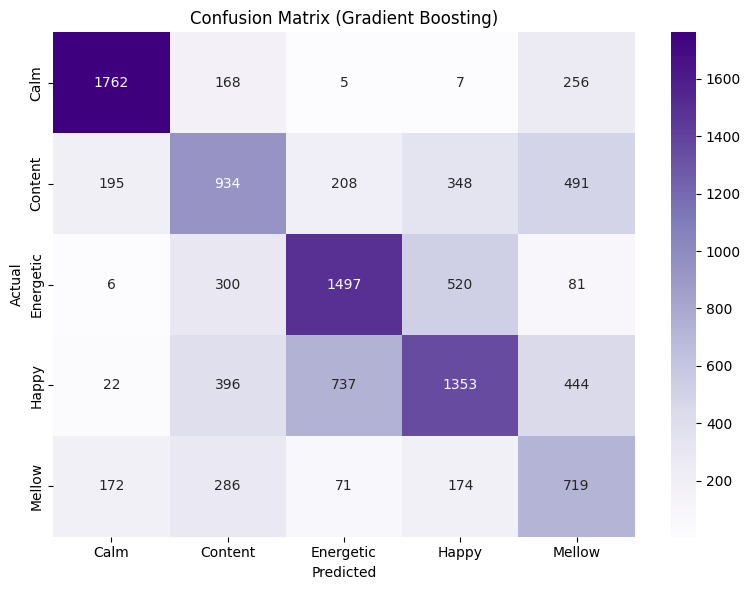

In [79]:
from sklearn.ensemble import GradientBoostingClassifier

# initializing with 100 trees
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_reduced, y_train_resampled)

y_val_pred = gb.predict(X_val_reduced)

# results 
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy (Gradient Boosting): {val_acc:.4f}")

print("\nClassification Report (Gradient Boosting):")
print(classification_report(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=confusion_labels, yticklabels=confusion_labels)
plt.title("Confusion Matrix (Gradient Boosting)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### <font color='6e6e6e'>XGBoost</font>

We chose to include the XGBoost model in our evaluation because it’s known to perform well on classification tasks involving structured/tabular data like ours. XGBoost is an advanced ensemble technique, working similarly to Gradient Boosting. We specifically chose to try XGBoost in addition to Gradient Boosting due to its enhanced speed and regularization capabilities, making it more efficient and robust for large datasets.

As shown in our results, this model achieved a validation accuracy of 0.5931 and a macro F1 score of 0.59, which is notably higher than the logistic regression baseline but still below ideal. This suggests that XGBoost captures more complex relationships in the data than a linear model but still leaves room for improvement. Looking at the classification report, the model performed best on Energetic (Cluster 2) with an F1 score of 0.63, and also did well on Calm with 0.82. However, clusters like Mellow and Content had lower F1 scores (0.45 and 0.49, respectively), indicating that they are often misclassified, likely due to overlapping feature distributions with other mood classes.

The confusion matrix reinforces this: Mellow is frequently misclassified, especially as Calm and Energetic. While Energetic and Happy performed moderately well, confusion between Calm and Happy persisted, echoing a challenge seen across other models in distinguishing emotional tones that share similar musical features.

Overall, this XGBoost result shows decent results for a pre tuned model. It performs better than logistic regression and captures more nuance than a basic model, but still falls short in overall balance. With further hyperparameter tuning, it could potentially match or outperform our top model.

XGBoost Validation Accuracy: 0.5931671449067432
              precision    recall  f1-score   support

        Calm       0.83      0.81      0.82      2198
     Content       0.50      0.48      0.49      2176
   Energetic       0.61      0.66      0.63      2404
       Happy       0.60      0.49      0.54      2952
      Mellow       0.40      0.53      0.45      1422

    accuracy                           0.59     11152
   macro avg       0.59      0.59      0.59     11152
weighted avg       0.60      0.59      0.59     11152



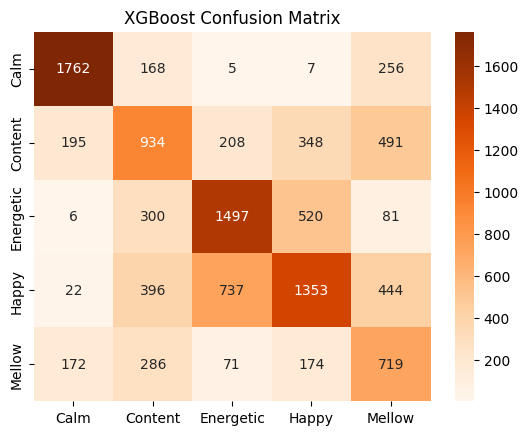

In [80]:
import warnings
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# encoding target feature 
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_resampled)
y_val_encoded = le.transform(y_val)

# just removing annoying warnings to keep the output clean 
warnings.filterwarnings("ignore", category=UserWarning, module='xgboost')

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb.fit(X_train_reduced, y_train_encoded)

y_val_pred_xgb = xgb.predict(X_val_reduced)


# converting encoded predictions back to original labels for easier evaluation 
y_val_pred_labels = le.inverse_transform(y_val_pred_xgb)

# results 
print("XGBoost Validation Accuracy:", accuracy_score(y_val, y_val_pred_labels))
print(classification_report(y_val, y_val_pred_labels))

cm_xgb = confusion_matrix(y_val, y_val_pred_labels)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=confusion_labels, yticklabels=confusion_labels)
plt.title("XGBoost Confusion Matrix")
plt.show()

### <font color='6e6e6e'>Random Forest</font>

Our Random Forest model achieved a validation accuracy of approximately 0.7592 and a macro F1 score of 0.76, which indicates a solid performance.

We chose to evaluate a Random Forest model because of its robustness and reputation for strong performance across many types of datasets, including ones with imbalanced classes (as we have). It works by building multiple decision trees and aggregating their results, which helps increase predictive stability. By averaging the predictions of a lot of trees, it balances out errors and captures non-linear relationships in the data.

This model outperformed all previous models and performed particularly well on the Calm and Energetic classes, with F1-scores of 0.87 and 0.78, showing that it could consistently identify these moods. It did seem to struggle more with Mellow, which had the lowest F1-score of 0.64, likely due to overlapping feature patterns with other moods. 

The confusion matrix supports these findings. The model classified most Calm, Content, and Energetic samples correctly, with minimal confusion across those three. However, there was some noticeable misclassification between Happy and Energetic, as well as between Mellow and Calm. This indicates that while the Random Forest model captures complex interactions between features, some mood categories still remain harder to separate. 

Validation Accuracy (Random Forest): 0.7592
Classification Report (Validation - Random Forest):
              precision    recall  f1-score   support

        Calm       0.86      0.89      0.87      2198
     Content       0.72      0.73      0.72      2176
   Energetic       0.77      0.80      0.78      2404
       Happy       0.78      0.70      0.74      2952
      Mellow       0.61      0.68      0.64      1422

    accuracy                           0.76     11152
   macro avg       0.75      0.76      0.75     11152
weighted avg       0.76      0.76      0.76     11152



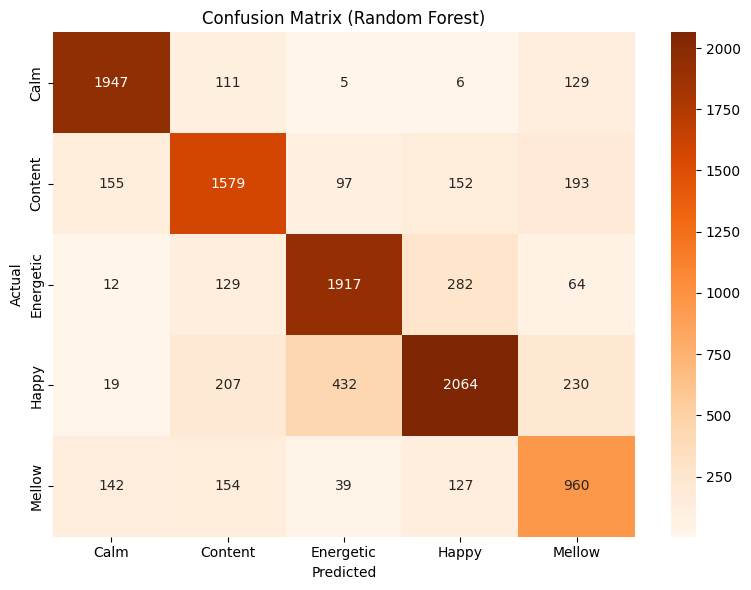

In [81]:
from sklearn.ensemble import RandomForestClassifier

# initializing 
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_reduced, y_train_resampled)

y_val_pred = rf.predict(X_val_reduced)

print(f"Validation Accuracy (Random Forest): {accuracy_score(y_val, y_val_pred):.4f}")
print("Classification Report (Validation - Random Forest):")
print(classification_report(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=confusion_labels, yticklabels=confusion_labels)
plt.title("Confusion Matrix (Random Forest)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### <font color='6e6e6e'>MLP</font>

We tested the Multilayer Perceptron (MLP) as a deeper, non-linear model to evaluate whether neural architectures could outperform simpler classifiers like logistic regression on our mood classification task.

MLPs are capable of capturing complex, non-linear relationships between features by stacking fully connected layers with activation functions. Given the multidimensional nature of audio data, we hypothesized that this complexity might help the model better distinguish between overlapping mood classes.

However, the results were mixed. The MLP achieved a validation accuracy of 56.8% and a macro F1 score of 0.56, which is slightly higher than the logistic regression baseline but still lower than both the Random Forest and XGBoost models.

The classification report showed that while the model performed well on classes like Calm (F1 = 0.81) and Energetic (F1 = 0.61), it struggled with more subtle mood categories such as Mellow (F1 = 0.42) and Content (F1 = 0.45). This uneven performance suggests the model may not generalize well across all clusters.

The confusion matrix supports this, revealing:
- Heavy misclassifications between Happy and Content
- Overlapping predictions for Calm and Mellow
- A tendency for the model to favor dominant classes, despite training on balanced data via SMOTE

These results suggest that while the MLP was able to model some non-linear patterns, it was still outperformed by tree-based ensembles, which handled mood distinctions more robustly in our pipeline.



MLP Validation Accuracy: 0.5680595408895266
              precision    recall  f1-score   support

        Calm       0.82      0.80      0.81      2198
     Content       0.45      0.45      0.45      2176
   Energetic       0.60      0.62      0.61      2404
       Happy       0.56      0.49      0.52      2952
      Mellow       0.38      0.47      0.42      1422

    accuracy                           0.57     11152
   macro avg       0.56      0.57      0.56     11152
weighted avg       0.58      0.57      0.57     11152



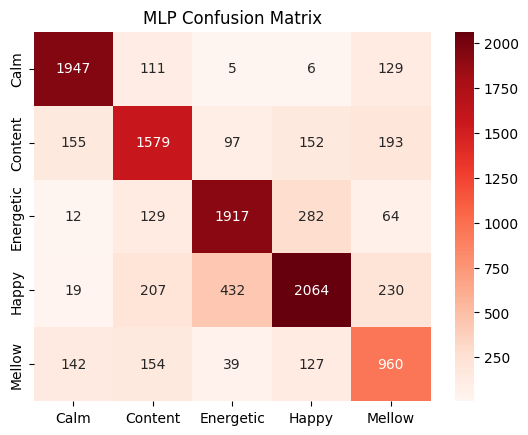

In [82]:
from sklearn.neural_network import MLPClassifier

# initializing with  100 hidden layers and a max of 300 iterations 
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=42)
mlp.fit(X_train_reduced, y_train_resampled)


y_val_pred_mlp = mlp.predict(X_val_reduced)

# results 
print("MLP Validation Accuracy:", accuracy_score(y_val, y_val_pred_mlp))
print(classification_report(y_val, y_val_pred_mlp))


cm_mlp = confusion_matrix(y_val, y_val_pred_mlp)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", xticklabels=confusion_labels, yticklabels=confusion_labels)
plt.title("MLP Confusion Matrix")
plt.show()

# <font color='#3c3c3c'>Hyperparameter Tuning</font>

### <font color='6e6e6e'>Gradient Boost</font>

The next step we undertook was to hyperparameter tune our advanced models, starting with Gradient Boosting. We tuned it using RandomizedSearchCV, focusing on the number of estimators, learning rate, and minimum samples required to split a node. These are key parameters when it comes to balancing model complexity and learning speed.

The tuned Gradient Boosting model achieved a validation accuracy of 0.5824 and a macro F1 score of 0.58, a fair improvement over the untuned version's 0.5618. This slight increase suggests that hyperparameter tuning did improve the model, though it may still not be the best fit for our task. Nevertheless, it outperformed the baseline models tested earlier.

The classification report showed results similar to the untuned version. The model continued to perform best on Calm and Energetic, with Energetic experiencing a slight increase in F1 score to 0.63. Meanwhile, Content, Happy, and Mellow continued to underperform, with F1 scores below 0.53.

The confusion matrix highlights the improvements and remaining challenges. Calm and Energetic are generally well classified, but Happy is frequently confused with Content and Energetic, while Mellow is still misclassified as Calm or Content. These misclassifications point to overlap in the acoustic features of lower-energy moods.

Overall, the tuned Gradient Boosting model showed slightly better balance across classes, demonstrating the benefits of hyperparameter tuning. However, other models may offer stronger overall results.

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Tuned Gradient Boosting Accuracy: 0.5824

Classification Report (Tuned Gradient Boosting):
              precision    recall  f1-score   support

        Calm       0.82      0.81      0.81      2198
     Content       0.48      0.47      0.47      2176
   Energetic       0.61      0.65      0.63      2404
       Happy       0.58      0.48      0.53      2952
      Mellow       0.39      0.50      0.44      1422

    accuracy                           0.58     11152
   macro avg       0.58      0.58      0.58     11152
weighted avg       0.59      0.58      0.58     11152



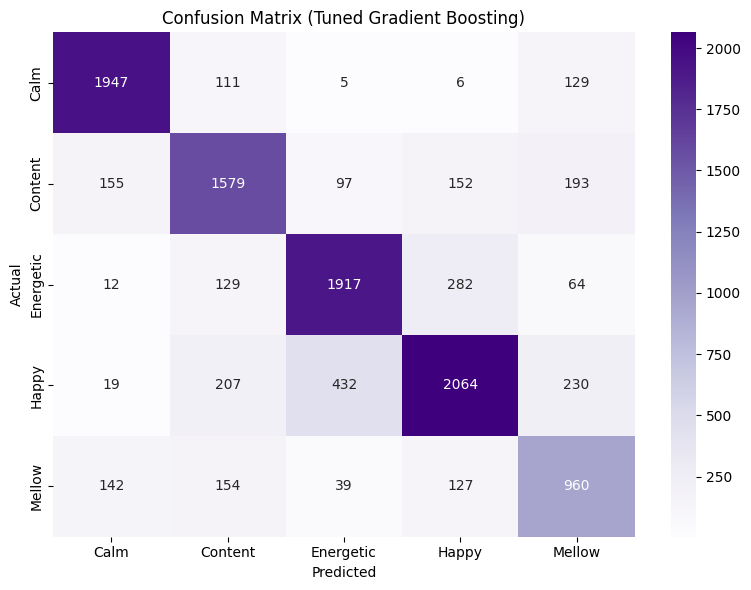

In [83]:
from sklearn.model_selection import RandomizedSearchCV

# defining parametrs 
gb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'min_samples_split': [2, 5, 10]
}

# using random search 
gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_params,
    n_iter=25,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='accuracy'
)


gb_search.fit(X_train_reduced, y_train_resampled)

best_gb = gb_search.best_estimator_

y_val_pred_gb_tuned = best_gb.predict(X_val_reduced)


# results 
val_acc_gb_tuned = accuracy_score(y_val, y_val_pred_gb_tuned)
print(f"Tuned Gradient Boosting Accuracy: {val_acc_gb_tuned:.4f}")
print("\nClassification Report (Tuned Gradient Boosting):")
print(classification_report(y_val, y_val_pred_gb_tuned))


cm_gb_tuned = confusion_matrix(y_val, y_val_pred_gb_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples", xticklabels=confusion_labels, yticklabels=confusion_labels)
plt.title("Confusion Matrix (Tuned Gradient Boosting)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### <font color='6e6e6e'>XGBoost</font>

After hyperparameter tuning using RandomizedSearchCV, the performance of the XGBoost model improved significantly. The validation accuracy increased from 0.5931 to 0.6592, and the macro F1 score improved to 0.65. This boost in performance shows the importance of tuning parameters like learning rate, depth, and subsampling to better adapt to the structure of our dataset.

Looking at the classification report, we see that the model performs particularly well for the Calm cluster, achieving an F1-score of 0.84, which indicates that this mood class is easier for the model to identify. The Energetic class also stands out with an F1-score of 0.69, thanks to improvements in recall.

However, like in the untuned version, performance is still weaker for the Mellow and Happy clusters, with F1-scores of 0.53 and 0.61 respectively. These moods may involve more subtle or overlapping features, making them harder to classify. For example, the confusion matrix shows frequent misclassifications between Mellow and Content, and between Happy and Energetic. This means the model likely struggles with separating similar emotional tones between these moods.

The confusion matrix confirms that most errors happen between adjacent or similar clusters, reinforcing the idea that some moods naturally share musical traits. But overall, despite these challenges, the tuned XGBoost model has a better balance across all classes compared to its untuned version and demonstrates strong generalization without overfitting.

Fitting 3 folds for each of 25 candidates, totalling 75 fits


/Users/gabyvega/ExpenseManagement/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [15:32:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/gabyvega/ExpenseManagement/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [15:32:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/gabyvega/ExpenseManagement/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [15:32:23] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/gabyvega/ExpenseManagement/.venv/lib/python3.13/site-packages/xgboost/training.py:183: UserWarning: [15:32:23] WARNING: /Users/runner/work/xgboost/xgboost/src/

Validation Accuracy (Tuned XGBoost): 0.6592

Classification Report:
              precision    recall  f1-score   support

        Calm       0.84      0.84      0.84      2198
     Content       0.61      0.61      0.61      2176
   Energetic       0.67      0.71      0.69      2404
       Happy       0.67      0.56      0.61      2952
      Mellow       0.47      0.59      0.53      1422

    accuracy                           0.66     11152
   macro avg       0.65      0.66      0.65     11152
weighted avg       0.67      0.66      0.66     11152



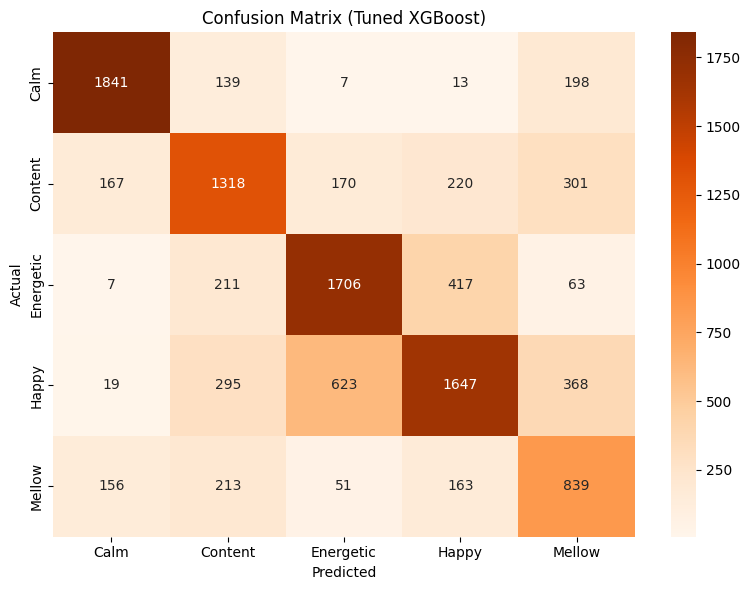

In [84]:
# encoding 
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train_resampled)
y_val_encoded = le.transform(y_val)

# setting up hyperparamters 
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

# random search with 25 combinations  
xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    param_distributions=xgb_params,
    n_iter=25,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='accuracy'
)

xgb_search.fit(X_train_reduced, y_train_encoded)

best_xgb = xgb_search.best_estimator_
y_val_pred_encoded = best_xgb.predict(X_val_reduced)
y_val_pred = le.inverse_transform(y_val_pred_encoded)

# results 
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy (Tuned XGBoost): {val_acc:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))

# confusion matrix 
y_val_pred_xgb_tuned = best_xgb.predict(X_val_reduced)
y_val_pred_labels = le.inverse_transform(y_val_pred_xgb_tuned)

cm = confusion_matrix(y_val, y_val_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=confusion_labels, yticklabels=confusion_labels)
plt.title("Confusion Matrix (Tuned XGBoost)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

### <font color='6e6e6e'>Random Forest</font>

To improve our Random Forest model performance, we used a coarse-to-fine hyperparameter tuning strategy. This strategy combines random search and grid search, meaning that we started with a broad search (coarse tuning) to explore wide parameter ranges, such as trying different values for number of estimators, tree depth, and split criteria. This helped us identify the general areas where the model performed best.

Once we obtained the best parameters from this initial search, we moved on to fine-tuning. In this stage, we narrowed the parameter ranges around the best coarse results, for example, zooming in around n_estimators = 100 and adjusting values like min_samples_split and max_depth with more precision. This two-step approach allowed us to save computation time while still finding well-optimized hyperparameters for our Random Forest model.

The best fine-tuned parameters were:
{'n_estimators': 120, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}

In [85]:
# defining a coarse hyperparameter grid 
coarse_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42)

# random search 
coarse_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=coarse_grid,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='accuracy'
)

coarse_search.fit(X_train_reduced, y_train_resampled)
print("Best coarse parameters:", coarse_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/gabyvega/ExpenseManagement/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Best coarse parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': None}


In [86]:
# fine tuned hyperparameters
fine_grid = {
    'n_estimators': [80, 100, 120],              # around 100
    'max_depth': [None, 10, 20],                 # exploring around None
    'min_samples_split': [2, 3, 4],              # around 2
    'min_samples_leaf': [1, 2],                  # around 1
}

rf = RandomForestClassifier(random_state=42)

fine_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=fine_grid,
    n_iter=20,
    cv=3,
    verbose=1,
    n_jobs=-1,
    scoring='accuracy',
    random_state=42
)

fine_search.fit(X_train_reduced, y_train_resampled)

print("Best fine-tuned parameters:", fine_search.best_params_)


Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/gabyvega/ExpenseManagement/.venv/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



Best fine-tuned parameters: {'n_estimators': 120, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_depth': None}


After applying fine-tuned hyperparameters to our Random Forest model, we managed to achieve a validation accuracy of 75.73%, with consistent performance across most classes. The model maintained strong precision and recall for the “Calm” and “Energetic” moods (both are above 0.77), but continued to struggle with the “Mellow” class (F1-score = 0.63), which is probably due to fewer distinct patterns or potential class overlap. The confusion matrix confirms this improvement since most classes are well classified, and overall misclassification dropped compared to our original baseline. The macro F1-score of 0.76 reflects this balanced performance across all classes. This tuned random forest gave us the best result post tuned (compared to the other models) which is why we will perform the final test evaluation using this model. 

Validation Accuracy: 0.7573

Classification Report:
              precision    recall  f1-score   support

        Calm       0.86      0.88      0.87      2198
     Content       0.72      0.72      0.72      2176
   Energetic       0.77      0.80      0.78      2404
       Happy       0.79      0.70      0.74      2952
      Mellow       0.60      0.67      0.63      1422

    accuracy                           0.76     11152
   macro avg       0.75      0.75      0.75     11152
weighted avg       0.76      0.76      0.76     11152



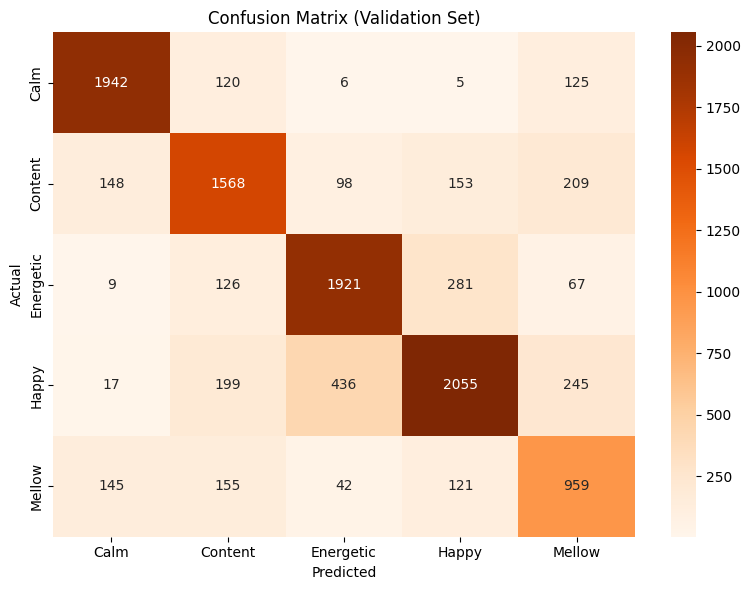

In [87]:
best_rf = fine_search.best_estimator_
y_val_pred = best_rf.predict(X_val_reduced)

report = classification_report(y_val, y_val_pred, output_dict=True)
val_acc = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_acc:.4f}\n")

print("Classification Report:")
print(classification_report(y_val, y_val_pred))

cm = confusion_matrix(y_val, y_val_pred, labels=confusion_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges", xticklabels=confusion_labels, yticklabels=confusion_labels)
plt.title("Confusion Matrix (Validation Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# <font color='#3c3c3c'>Final Model</font>

Our final test model using our previously fine-tuned Random Forest classifier achieved a strong accuracy of 76.31% on unseen data, with consistent performance across multiple different metrics. The classification report shows particularly high precision and recall for the Calm and Energetic classes, with F1-scores of 0.86 and 0.79, respectively. Mellow still remains the most difficult mood to classify, with a lower F1-score of 0.63, which is most likely due to its overlap with other emotional tones.

The confusion matrix further confirms these trends. The model is consistently accurate for most classes, but there is still noticeable confusion between Mellow, Happy, and Content. This is expected and makes logical sense, as these moods may share similar acoustic features like tempo or speechiness. Regardless, the matrix shows clear diagonal dominance, indicating good generalization and minimal overfitting.

These results serve as further proof that the coarse-to-fine tuning approach and feature reduction efforts were successful. The Random Forest model, with its ability to handle non-linear relationships and feature interactions, ended up being a robust final choice for our mood classification task. The model achieved a macro F1-score of 0.75, reinforcing its balanced performance across all mood categories.

Test Accuracy: 0.7631

Classification Report:
              precision    recall  f1-score   support

        Calm       0.86      0.87      0.86      2199
     Content       0.74      0.72      0.73      2175
   Energetic       0.78      0.81      0.79      2405
       Happy       0.79      0.72      0.75      2952
      Mellow       0.60      0.67      0.63      1422

    accuracy                           0.76     11153
   macro avg       0.75      0.76      0.75     11153
weighted avg       0.77      0.76      0.76     11153



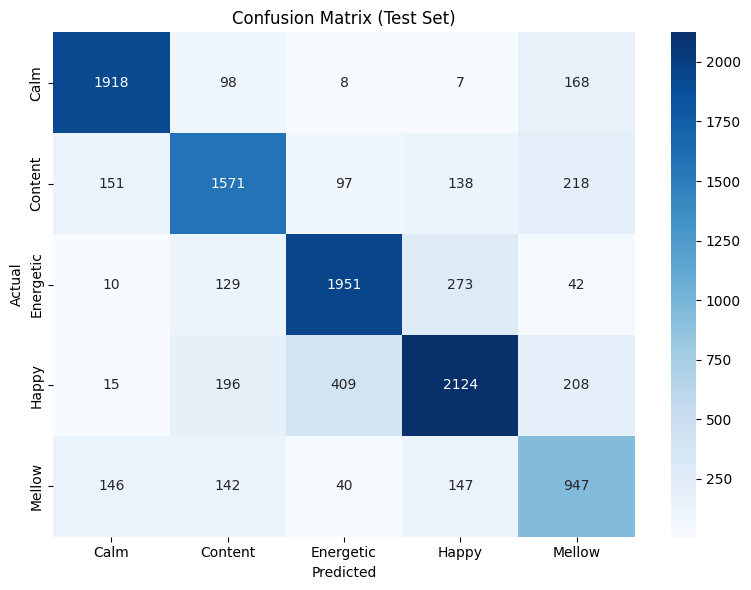

In [88]:
# combining training and validation sets into one 
X_full_train = pd.concat([X_train_reduced, X_val_reduced])
y_full_train = pd.concat([y_train_resampled, y_val])

# retraining on the full training set
final_rf = fine_search.best_estimator_
final_rf.fit(X_full_train, y_full_train)

# predicting on the test set
y_test_pred = final_rf.predict(X_test_reduced)

# test accuracy
test_acc = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report:")
report = classification_report(y_test, y_test_pred, output_dict=True)
print(classification_report(y_test, y_test_pred))

cm_test = confusion_matrix(y_test, y_test_pred, labels=confusion_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_test, annot=True, fmt="d", cmap="Blues", xticklabels=confusion_labels, yticklabels=confusion_labels)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


To further evaluate the performance of our final model, we plotted a multiclass ROC (Receiver Operating Characteristic) curve for the test set. Each curve represents a one-vs-rest classification for one mood class, showing how well the model separates each class from the others.

Key Observations:
- AUC (Area Under Curve) values are all above 0.90, which shows great discriminative ability across all mood categories.
- Calm has the highest AUC at around 0.98, showing that its the most easily distinguishable mood in our dataset.
- Energetic follows with around n0.96, also showing strong separability.
- Content, Happy, and Mellow are slightly lower but still strong at around 0.94, 0.94, and 0.93, respectively.

The closer a curve hugs the top-left corner, the better the model is at classifying that mood. The diagonal dashed line represents random guessing (AUC = 0.5). Since all our curves are well above it, the model performs much better than chance.

These ROC results reinforce our previous findings from the classification report and confusion matrix: the model has strong predictive power, especially for Calm and Energetic, and handles subtler mood classes like Mellow quite well too. The high AUC values demonstrate that the Random Forest model generalizes effectively and maintains high sensitivity and specificity for each class.

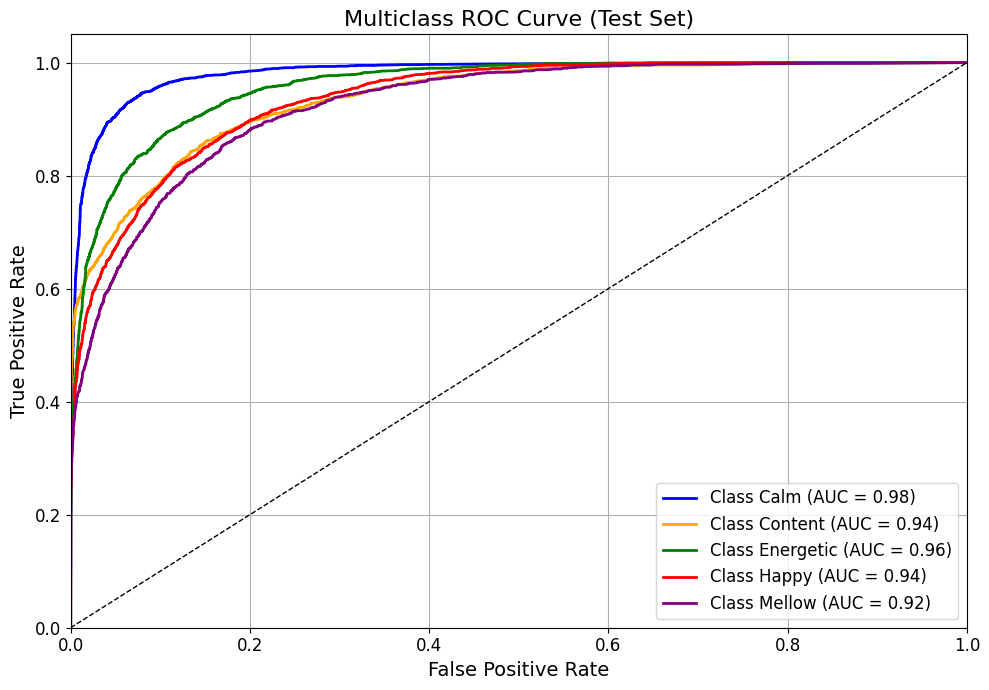

In [89]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = final_rf.predict_proba(X_test_reduced)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 7))
colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, color in zip(range(len(classes)), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'Class {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('Multiclass ROC Curve (Test Set)', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

Finally, we decided to print 10 prediction examples our model was making along with the track name, the artist name, and their actual cluster label. This just serves as a quick "prototype" of our model

In [90]:
results_df = pd.DataFrame({
    "track_name": X_test_meta["track_name"],
    "artist_name": X_test_meta["artist_name"],
    "Actual Mood": y_test.values,
    "Predicted Mood": y_test_pred,
})

results_df["Correct"] = results_df["Actual Mood"] == results_df["Predicted Mood"]

In [91]:
print(results_df.head(10))  # showing first 10 predictions

#cluster 0: 
#cluster 1: 
#cluster 2: 
#cluster 3: 
#cluster 4: 

                                          track_name  \
0  Debussy: Clair de Lune - Leopold Stokowksi Tra...   
1                    Luminomagifantastique (reprise)   
2                       Lean Back (feat. Dion Davis)   
3                                     Yefikir Tizita   
4                                Hallelujah Junction   
5                                          Traphouse   
6                                              AAAAA   
7                                 What You Gonna Do?   
8                                      Mr. Policeman   
9  Madama Butterfly, Act I: L'Imperial Commissari...   

                  artist_name Actual Mood Predicted Mood  Correct  
0           Leopold Stokowski        Calm           Calm     True  
1               Léovanie Raud      Mellow         Mellow     True  
2          Capital City Music        Calm           Calm     True  
3              Mulatu Astatke      Mellow        Content    False  
4                  John Adams      Mellow  

### <font color='6e6e6e'>Final Conclusions</font>

Our project set out to explore whether machine learning could be used to predict a song’s mood based on its audio features. We began by defining mood labels through unsupervised clustering, then trained and compared multiple supervised models, from simple baselines like logistic regression to advanced ensemble techniques like XGBoost and Random Forest.

Throughout the pipeline, we addressed key challenges such as class imbalance, ambiguous mood labels, and potential data leakage. By applying robust preprocessing techniques and hyperparameter tuning, we gradually improved our models ability to generalize across mood categories. In the end, the Random Forest model had the best performance, achieving a macro F1-score of 0.75 and test accuracy of 76.31%, supported by strong ROC AUC values across all classes.

These results show that audio features do indeed offer a valuable foundation, but mood classification is still inherently subjective and affected by overlapping traits across emotions. Our work demonstrates the importance of using a thoughtful modeling strategy, including careful evaluation metrics, feature engineering, and tuning.

Ultimately, this project highlights both the promise and the limitations of mood classification using machine learning. It lays the groundwork for future improvements, especially through multimodal learning, that combines audio, lyrics, and metadata to better understand music’s emotional impact.

# <font color='#3c3c3c'>Inference</font>

Please refer to the README.md file to learn more about how to use this section.

Function to get features directly from Spotify API

In [92]:
def get_features_from_spotify(track_name, sp):
   import pandas as pd


   # Search for the track
   results = sp.search(q=track_name, limit=1, type='track')
   if not results['tracks']['items']:
       print("Song not found.")
       return None


   track_id = results['tracks']['items'][0]['id']
   features = sp.audio_features([track_id])[0]


   if features is None:
       print("Could not retrieve audio features.")
       return None


   # One-hot encode key and time signature
   key_labels = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
   ts_labels = ['1/4', '3/4', '4/4', '5/4']


   key = key_labels[features['key']]
   ts = f"{features['time_signature']}/4"


   key_onehot = {f"key_{k}": int(k == key) for k in ['A#', 'B', 'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#']}
   ts_onehot = {f"time_signature_{t}": int(t == ts) for t in ['1/4', '3/4', '5/4']}


   model_input = {
       'danceability': features['danceability'],
       'instrumentalness': features['instrumentalness'],
       'liveness': features['liveness'],
       'loudness': features['loudness'],
       'mode': features['mode'],
       'speechiness': features['speechiness'],
       'tempo': features['tempo'],
   }
   model_input.update(key_onehot)
   model_input.update(ts_onehot)


   return pd.DataFrame([model_input])

Function that predicts from the function that gathers the features through a df

In [93]:
def predict_mood_from_df(input_df):
   import matplotlib.pyplot as plt


   # Predict using the trained model
   prediction = final_rf.predict(input_df)[0]
   probabilities = final_rf.predict_proba(input_df)[0]


   print(f"\n🎧 Predicted Mood: **{prediction}**")
   print("Class Probabilities:")
   for mood, prob in zip(final_rf.classes_, probabilities):
       print(f" - {mood}: {prob:.2f}")


   # Plotting the probabilities
   plt.figure(figsize=(8, 5))
   bars = plt.bar(final_rf.classes_, probabilities, color='skyblue')
   plt.title("Predicted Mood Probabilities", fontsize=14)
   plt.xlabel("Mood Classes", fontsize=12)
   plt.ylabel("Probability", fontsize=12)
   plt.ylim(0, 1)


   for bar in bars:
       yval = bar.get_height()
       plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}",
                ha='center', va='bottom', fontsize=10)


   plt.tight_layout()
   plt.grid(axis='y', linestyle='--', alpha=0.6)
   plt.show()


Function to manually input the features

In [94]:
def predict_mood_manual_input():
   import pandas as pd
   import numpy as np
   import matplotlib.pyplot as plt


   # Define feature names in order (matching X_train_reduced)
   feature_names = ['danceability', 'instrumentalness', 'liveness', 'loudness', 'mode',
                    'speechiness', 'tempo', 'key_A#', 'key_B', 'key_C', 'key_C#', 'key_D',
                    'key_D#', 'key_E', 'key_F', 'key_F#', 'key_G', 'key_G#',
                    'time_signature_1/4', 'time_signature_3/4', 'time_signature_5/4']


   print("\nEnter the values for each feature (you can press enter to use default 0):")
   input_data = []


   for feat in feature_names:
       try:
           val = input(f"{feat}: ")
           input_data.append(float(val) if val.strip() != "" else 0.0)
       except:
           print("Invalid input. Setting to 0.0 by default.")
           input_data.append(0.0)


   # Convert to DataFrame
   X_input = pd.DataFrame([input_data], columns=feature_names)


   # Predict using the final model
   prediction = final_rf.predict(X_input)[0]
   probabilities = final_rf.predict_proba(X_input)


   print(f"\nPredicted Mood: **{prediction}**")
   print("Class Probabilities:")
   for mood, prob in zip(final_rf.classes_, probabilities[0]):
       print(f" - {mood}: {prob:.2f}")


   # Plotting the probabilities as a bar chart
   plt.figure(figsize=(8, 5))
   bars = plt.bar(final_rf.classes_, probabilities, color='skyblue')
   plt.title("Predicted Mood Probabilities", fontsize=14)
   plt.xlabel("Mood Classes", fontsize=12)
   plt.ylabel("Probability", fontsize=12)
   plt.ylim(0, 1)


   # Add probability labels on top of bars
   for bar in bars:
       yval = bar.get_height()
       plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02, f"{yval:.2f}",
                ha='center', va='bottom', fontsize=10)


   plt.tight_layout()
   plt.grid(axis='y', linestyle='--', alpha=0.6)
   plt.show()


In order to call these functions we would have to use:

In [95]:
!pip3 install spotipy


[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip


In [96]:
import spotipy
from spotipy.oauth2 import SpotifyClientCredentials


# Replace these with your real credentials
client_id ="YOUR-CLIENT-ID-KEY"
client_secret = "YOUR-SECRET-KEY"

auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(auth_manager=auth_manager)

In [ ]:
track = sp.search(q="SONG-NAME", limit=1, type="track")
print(track["tracks"]["items"][0]["name"], "-", track["tracks"]["items"][0]["id"])

If it outputs a track id then we know the song exist and we can proceed and run this:

In [ ]:
# Authenticate once here
from spotipy.oauth2 import SpotifyClientCredentials
import spotipy


client_id ="YOUR-CLIENT-ID-KEY"
client_secret = "YOUR-SECRET-KEY"


auth_manager = SpotifyClientCredentials(client_id=client_id, client_secret=client_secret)
sp = spotipy.Spotify(auth_manager=auth_manager)


# Now pass `sp` to your function
df = get_features_from_spotify("The Color Violet", sp)


if df is not None:
   predict_mood_from_df(df)


Or input the features manually with:

In [ ]:
predict_mood_manual_input()